# ImageWoof transfer attacks — TransferAttack + MDCS official code

**Главный Kaggle notebook.**

Что делает notebook:

1. Клонирует официальный репозиторий **MDCS_attack**, внутри которого лежит их fork **TransferAttack**.
2. Импортирует готовые реализации:
   - MI-FGSM
   - MDCS-MI
   - SSM
   - OPS
   - MDCS-OPS
   - CWT-MI-FGSM
   - CWT-MDCS-MI
   - CWT-SSM
   - CWT-OPS
   - CWT-MDCS-OPS
   - BSR-MI-FGSM
   - BSR-MDCS-MI
   - BSR-SSM
   - BSR-OPS
   - BSR-MDCS-OPS
   - MEF (official MEFAttack adapter)
3. Загружает ImageWoof.
4. Для ResNet18, ResNeXt50, ViT-Tiny и Swin-Tiny:
   - либо загружает уже готовый 10-class ImageWoof checkpoint,
   - либо берет ImageNet weights / ImageNet checkpoint,
   - заменяет classification head на 10 классов,
   - **замораживает backbone и обучает только голову**,
   - сохраняет новый checkpoint.
5. Использует **ResNet18 как единственный surrogate**.
6. Генерирует adversarial tensors через код TransferAttack/MDCS; CWT/BSR-варианты динамически расширяют вход surrogate, не переписывая базовые атаки.
7. Считает white-box и transfer ASR на ResNet18 / ResNeXt50 / ViT-Tiny / Swin-Tiny.
8. Transfer ASR считается только на `common-clean-correct` объектах.
9. Опционально делает JPEG stress test Q=90/70/50.
10. Логирует итоговые таблицы и matplotlib figures в ClearML, но локальный вывод всегда остается основным.
11. Сохраняет checkpoints, batches, configs, CSV и plots в `/kaggle/working`.\n
**Важно:** TransferAttack возвращает `delta`, поэтому adversarial image строится как `x_adv = clamp(x + delta, 0, 1)`.
PNG для основной оценки не используется. Сохраняются `.pt` tensors.

**ClearML v4:** используется проверенная Kaggle-конфигурация `access_key` / `secret_key` и фиксированные ClearML hosts.

### Подготовка архива ImageWoof

Архив автоматически ищется в `/kaggle/input`. Фактическая идемпотентная распаковка выполняется в `/tmp` в ячейке проверки структуры.

In [98]:
from pathlib import Path

ARCHIVE = Path("/kaggle/input/datasets/renrgaming2000/imagewoof2-329/imagewoof2-320.tgz")
print("Configured ImageWoof archive:", ARCHIVE)
print("If this exact path is absent, the structure cell will search all /kaggle/input.")

Configured ImageWoof archive: /kaggle/input/datasets/renrgaming2000/imagewoof2-329/imagewoof2-320.tgz
If this exact path is absent, the structure cell will search all /kaggle/input.


## 0. Конфигурация — сначала заполнить этот блок

In [99]:
from pathlib import Path

# ==============================
# DATA
# ==============================
# ОБЯЗАТЕЛЬНЫЙ Kaggle Input: только ImageWoof.
# Должна быть папка с:
# DATA_ROOT/train/<10 ImageWoof class folders>
# DATA_ROOT/val/<10 ImageWoof class folders>
#
# Отдельно добавлять ImageNet weights в Kaggle Input НЕ НУЖНО,
# если Internet=ON: torchvision/timm сами скачивают official pretrained weights.
# Локальные pretrained checkpoints — только опциональный offline/reproducibility вариант.
DATA_ROOT = Path("/kaggle/working/imagewoof2-320")
if not (DATA_ROOT / "train").exists() and (DATA_ROOT / "imagewoof2-320" / "train").exists():
    DATA_ROOT = DATA_ROOT / "imagewoof2-320"

IMAGE_SIZE = 224
NUM_CLASSES = 10
SEED = 42
NUM_WORKERS = 2

# ==============================
# MODE / OUTPUT
# ==============================
# Первый запуск:
# RUN_ID = "smoke_mifgsm"
# NUM_ATTACK_SAMPLES = 20
# METHODS_TO_RUN = ["mifgsm"]
#
# Второй smoke:
# RUN_ID = "smoke_all"
# NUM_ATTACK_SAMPLES = 20
# METHODS_TO_RUN = ["mifgsm", "mdcs_mi", "ssm", "ops", "mdcs_ops"]
#
# Финал:
# RUN_ID = "final200"
# NUM_ATTACK_SAMPLES = 200
RUN_ID = "smoke_mifgsm"
NUM_ATTACK_SAMPLES = 20
METHODS_TO_RUN = ["mifgsm"]

WORK_ROOT = Path("/kaggle/working/adversarial_transfer_imagewoof")
RUN_ROOT = WORK_ROOT / RUN_ID
CHECKPOINT_OUT_DIR = WORK_ROOT / "imagewoof_head_checkpoints"

RUN_ROOT.mkdir(parents=True, exist_ok=True)
CHECKPOINT_OUT_DIR.mkdir(parents=True, exist_ok=True)

# ==============================
# MODELS
# ==============================
# imagewoof_checkpoint:
#   готовый checkpoint модели с 10-class head.
#
# imagenet_checkpoint:
#   опциональный локальный checkpoint ImageNet (1000 classes).
#   Если его нет, notebook скачает официальные ImageNet pretrained weights.
#
# Если уже есть готовый ImageWoof checkpoint для ResNet18 из предыдущего baseline,
# укажите его в imagewoof_checkpoint и модель НЕ будет переобучаться.
MODEL_SPECS = {
    "resnet18": {
        "family": "torchvision",
        "arch": "resnet18",
        "imagewoof_checkpoint": None,
        "imagenet_checkpoint": None,
    },
    "resnext50": {
        "family": "torchvision",
        "arch": "resnext50_32x4d",
        "imagewoof_checkpoint": None,
        "imagenet_checkpoint": None,
    },
    "vit_tiny": {
        "family": "timm",
        # Explicit ImageNet-1k fine-tuned pretrained variant for reproducibility.
        "arch": "vit_tiny_patch16_224.augreg_in21k_ft_in1k",
        "imagewoof_checkpoint": None,
        "imagenet_checkpoint": None,
    },
    "swin_tiny": {
        "family": "timm",
        # Explicit ImageNet-1k pretrained variant for reproducibility.
        "arch": "swin_tiny_patch4_window7_224.ms_in1k",
        "imagewoof_checkpoint": None,
        "imagenet_checkpoint": None,
    },
}

SOURCE_NAME = "resnet18"

# Если imagewoof_checkpoint не задан:
ALLOW_DOWNLOAD_IMAGENET_WEIGHTS = True
FORCE_RETRAIN_HEADS = False

# Только classification head, backbone frozen.
HEAD_EPOCHS = 4
HEAD_LR = 1e-3
HEAD_WEIGHT_DECAY = 1e-4
HEAD_BATCH_SIZE = 64
HEAD_EARLY_STOP_PATIENCE = 2

# ==============================
# ATTACKS
# ==============================
EPS = 16 / 255
STEPS = 10
ALPHA = 1.6 / 255
DECAY = 1.0

# Для smoke тяжелые методы намеренно дешевые.
SMOKE = RUN_ID.startswith("smoke")

ATTACK_CONFIG = {
    "mifgsm": {
        "batch_size": 8,
        "kwargs": dict(
            epsilon=EPS, alpha=ALPHA, epoch=STEPS, decay=DECAY,
            targeted=False, random_start=False, norm="linfty",
        ),
    },
    "mdcs_mi": {
        "batch_size": 8,
        "kwargs": dict(
            epsilon=EPS, epoch=STEPS, decay=DECAY, mdcs_gamma=1.8,
            targeted=False, random_start=False, norm="linfty",
        ),
    },
    "ssm": {
        "batch_size": 2 if SMOKE else 4,
        "kwargs": dict(
            epsilon=EPS, alpha=ALPHA, epoch=STEPS, decay=DECAY,
            num_spectrum=2 if SMOKE else 20, rho=0.5,
            targeted=False, random_start=False, norm="linfty",
        ),
    },
    "ops": {
        "batch_size": 1 if SMOKE else 2,
        "kwargs": dict(
            epsilon=EPS, epoch=STEPS, decay=DECAY, beta=2.0,
            num_sample_neighbor=1 if SMOKE else 5,
            num_sample_operator=1 if SMOKE else 5,
            targeted=False, random_start=False, norm="linfty",
        ),
    },
    "mdcs_ops": {
        "batch_size": 1 if SMOKE else 2,
        "kwargs": dict(
            epsilon=EPS, epoch=STEPS, decay=DECAY, beta=2.0,
            num_sample_neighbor=1 if SMOKE else 5,
            num_sample_operator=1 if SMOKE else 5,
            mdcs_gamma=1.8,
            targeted=False, random_start=False, norm="linfty",
        ),
    },
}

# JPEG — вторичная проверка, не основная метрика.
RUN_JPEG = False if RUN_ID == "smoke_mifgsm" else True
JPEG_QUALITIES = [90, 70, 50]

# ==============================
# CLEARML
# ==============================
CLEARML_PROJECT = "adversarial-attacks"

# По умолчанию включено.
ENABLE_CLEARML = True

# Если нужен новый непересекающийся subset, перечислите здесь прошлые RUN_ID.
# Их subset_indices.npy будут исключены при выборе текущих изображений.
EXCLUDE_RUN_IDS = []

# Если True, в текущий ClearML task будут дополнительно залогированы
# объединенные результаты по EXCLUDE_RUN_IDS + текущему RUN_ID.
LOG_COMBINED_RESULTS = True

print("RUN_ID:", RUN_ID)
print("RUN_ROOT:", RUN_ROOT)
print("SMOKE:", SMOKE)
print("METHODS:", METHODS_TO_RUN)

RUN_ID: smoke_mifgsm
RUN_ROOT: /kaggle/working/adversarial_transfer_imagewoof/smoke_mifgsm
SMOKE: True
METHODS: ['mifgsm']


In [100]:
# Transformation extensions: keep every baseline and add CWT/BSR variants.
BASE_METHODS = ('mifgsm', 'mdcs_mi', 'ssm', 'ops', 'mdcs_ops')
CWT_BASE_METHODS = {
    'cwt_mifgsm': 'mifgsm',
    'cwt_mdcs_mi': 'mdcs_mi',
    'cwt_ssm': 'ssm',
    'cwt_ops': 'ops',
    'cwt_mdcs_ops': 'mdcs_ops',
}
BSR_BASE_METHODS = {
    'bsr_mifgsm': 'mifgsm',
    'bsr_mdcs_mi': 'mdcs_mi',
    'bsr_ssm': 'ssm',
    'bsr_ops': 'ops',
    'bsr_mdcs_ops': 'mdcs_ops',
}
ALL_METHODS = (*BASE_METHODS, *CWT_BASE_METHODS, *BSR_BASE_METHODS)

# Default representative run: designed for roughly one Kaggle GPU hour when checkpoints are ready.
RUN_PROFILE = 'hour'
RUN_PROFILES = {
    'fast': {
        'run_id': 'smoke_cwt_bsr_fast',
        'samples': 5,
        'steps': 3,
        'cwt_copies': 2,
        'bsr_copies': 2,
        'mef_samples': 2,
        'ssm_spectra': 1,
        'ops_neighbors': 1,
        'ops_operators': 1,
        'run_jpeg': False,
    },
    'hour': {
        # 5 images per class, all baseline/CWT/BSR methods plus MEF.
        'run_id': 'hour_cwt_bsr_all_50',
        'samples': 50,
        'steps': 5,
        'cwt_copies': 2,
        'bsr_copies': 2,
        'mef_samples': 3,
        'ssm_spectra': 2,
        'ops_neighbors': 2,
        'ops_operators': 2,
        'run_jpeg': False,
    },
    'balanced': {
        # More stable transformation averaging, but usually longer than one hour.
        'run_id': 'balanced_cwt_bsr_all',
        'samples': 50,
        'steps': 5,
        'cwt_copies': 4,
        'bsr_copies': 4,
        'mef_samples': 4,
        'ssm_spectra': 2,
        'ops_neighbors': 2,
        'ops_operators': 2,
        'run_jpeg': False,
    },
}
if RUN_PROFILE not in RUN_PROFILES:
    raise ValueError(f'Unknown RUN_PROFILE: {RUN_PROFILE}')

ACTIVE_PROFILE = dict(RUN_PROFILES[RUN_PROFILE])
RUN_ID = ACTIVE_PROFILE['run_id']
NUM_ATTACK_SAMPLES = ACTIVE_PROFILE['samples']
METHODS_TO_RUN = [*ALL_METHODS, 'mef']
STEPS = ACTIVE_PROFILE['steps']
ALPHA = EPS / STEPS
CWT_COPIES = ACTIVE_PROFILE['cwt_copies']
BSR_COPIES = ACTIVE_PROFILE['bsr_copies']
SMOKE = RUN_PROFILE == 'fast'
CWT_SETTINGS = {
    'grid': 2,
    'copies': CWT_COPIES,
    'scale_min': 1.0,
    'scale_max': 1.3,
    'max_angle': 26.0,
    'rotated_blocks': 2,
    'align_corners': False,
    'antialias': False,
}
BSR_SETTINGS = {
    'copies': BSR_COPIES,
    'num_block': 3,
    'max_degrees': 24.0,
}

# Apply one common step budget to every baseline before cloning CWT variants.
for base_method in BASE_METHODS:
    ATTACK_CONFIG[base_method]['kwargs']['epoch'] = STEPS
    if 'alpha' in ATTACK_CONFIG[base_method]['kwargs']:
        ATTACK_CONFIG[base_method]['kwargs']['alpha'] = ALPHA

ATTACK_CONFIG['ssm']['batch_size'] = 2 if SMOKE else 4
ATTACK_CONFIG['ssm']['kwargs']['num_spectrum'] = ACTIVE_PROFILE['ssm_spectra']
for expensive_method in ('ops', 'mdcs_ops'):
    ATTACK_CONFIG[expensive_method]['batch_size'] = 1 if SMOKE else 2
    ATTACK_CONFIG[expensive_method]['kwargs']['num_sample_neighbor'] = ACTIVE_PROFILE['ops_neighbors']
    ATTACK_CONFIG[expensive_method]['kwargs']['num_sample_operator'] = ACTIVE_PROFILE['ops_operators']

for cwt_method, base_method in CWT_BASE_METHODS.items():
    base_config = ATTACK_CONFIG[base_method]
    ATTACK_CONFIG[cwt_method] = {
        'batch_size': 1,
        'kwargs': {
            **dict(base_config['kwargs']),
            '_base_method': base_method,
            '_cwt_config': dict(CWT_SETTINGS),
        },
    }

for bsr_method, base_method in BSR_BASE_METHODS.items():
    base_config = ATTACK_CONFIG[base_method]
    ATTACK_CONFIG[bsr_method] = {
        'batch_size': 1,
        'kwargs': {
            **dict(base_config['kwargs']),
            '_base_method': base_method,
            '_bsr_config': dict(BSR_SETTINGS),
        },
    }

# MEF comes from its official repository and is not wrapped as CWT/BSR.
ATTACK_CONFIG['mef'] = {
    'batch_size': 1 if SMOKE else 2,
    'kwargs': {
        'epsilon': EPS,
        'step_size': ALPHA,
        'inner_mu': 0.9,
        'outer_mu': 0.5,
        'gamma': 2.0,
        'kesai': 0.15,
        'sample_num': ACTIVE_PROFILE['mef_samples'],
        'iteration_num': STEPS,
    },
}

BASE_METHOD_LABELS = {
    'mifgsm': 'MI-FGSM', 'mdcs_mi': 'MDCS-MI', 'ssm': 'SSM',
    'ops': 'OPS', 'mdcs_ops': 'MDCS-OPS',
}
METHOD_ORDER = list(METHODS_TO_RUN)
METHOD_LABELS = dict(BASE_METHOD_LABELS)
METHOD_LABELS.update({name: f'CWT-{BASE_METHOD_LABELS[base]}' for name, base in CWT_BASE_METHODS.items()})
METHOD_LABELS.update({name: f'BSR-{BASE_METHOD_LABELS[base]}' for name, base in BSR_BASE_METHODS.items()})
METHOD_LABELS['mef'] = 'MEF'

RUN_ROOT = WORK_ROOT / RUN_ID
RUN_ROOT.mkdir(parents=True, exist_ok=True)
CHECKPOINT_OUT_DIR.mkdir(parents=True, exist_ok=True)
RUN_JPEG = ACTIVE_PROFILE['run_jpeg']

print('CWT run profile:', RUN_PROFILE, ACTIVE_PROFILE)
print('CWT/BSR pipeline RUN_ID:', RUN_ID)
print('RUN_ROOT:', RUN_ROOT)
print('METHODS:', METHODS_TO_RUN)
print('CWT copies:', CWT_COPIES)
print('BSR copies:', BSR_COPIES)

CWT run profile: hour {'run_id': 'hour_cwt_bsr_all_50', 'samples': 50, 'steps': 5, 'cwt_copies': 2, 'bsr_copies': 2, 'mef_samples': 3, 'ssm_spectra': 2, 'ops_neighbors': 2, 'ops_operators': 2, 'run_jpeg': False}
CWT/BSR pipeline RUN_ID: hour_cwt_bsr_all_50
RUN_ROOT: /kaggle/working/adversarial_transfer_imagewoof/hour_cwt_bsr_all_50
METHODS: ['mifgsm', 'mdcs_mi', 'ssm', 'ops', 'mdcs_ops', 'cwt_mifgsm', 'cwt_mdcs_mi', 'cwt_ssm', 'cwt_ops', 'cwt_mdcs_ops', 'bsr_mifgsm', 'bsr_mdcs_mi', 'bsr_ssm', 'bsr_ops', 'bsr_mdcs_ops', 'mef']
CWT copies: 2
BSR copies: 2


### Какие pretrained weights нужны?

**Для обычного запуска в Kaggle вручную добавлять веса моделей в `Input` не нужно.**
Обязателен только ImageWoof. При `Internet=ON` notebook сам загрузит official pretrained weights:

- `torchvision.models.resnet18(weights="DEFAULT")`
- `torchvision.models.resnext50_32x4d(weights="DEFAULT")`
- `timm`: `vit_tiny_patch16_224.augreg_in21k_ft_in1k`
- `timm`: `swin_tiny_patch4_window7_224.ms_in1k`

После этого ImageNet classifier заменяется на 10-class ImageWoof head, backbone замораживается,
голова обучается и сохраняется в `/kaggle/working`.

Поля `imagenet_checkpoint` нужны только если вы **специально хотите использовать заранее скачанные локальные веса**
(например, для полностью offline запуска). Поля `imagewoof_checkpoint` нужны, если уже есть готовые 10-class модели.

## 1. Установка зависимостей и официальный TransferAttack/MDCS fork

### ClearML — установка

Используется тот же способ установки, что и в уже рабочем Kaggle-ноутбуке.

In [101]:
!pip install clearml -q

In [102]:
import sys
import subprocess
from pathlib import Path

# НЕ ставим requirements.txt репозитория целиком:
# он фиксирует очень старый torch/torchvision и может сломать Kaggle runtime.
# Ставим только недостающие зависимости.
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "timm>=0.6.12", "scikit-optimize"],
    check=True,
)

MDCS_REPO = Path("/kaggle/working/MDCS_attack")
MDCS_URL = "https://github.com/AndssY/MDCS_attack.git"

if not MDCS_REPO.exists():
    subprocess.run(
        ["git", "clone", "--depth", "1", MDCS_URL, str(MDCS_REPO)],
        check=True,
    )

MEF_REPO = Path("/kaggle/working/MEFAttack")
MEF_URL = "https://github.com/SignedQiu/MEFAttack.git"
if not MEF_REPO.exists():
    subprocess.run(
        ["git", "clone", "--depth", "1", MEF_URL, str(MEF_REPO)],
        check=True,
    )

TRANSFERATTACK_ROOT = MDCS_REPO / "TransferAttack"
assert TRANSFERATTACK_ROOT.exists(), TRANSFERATTACK_ROOT

repo_commit = subprocess.check_output(
    ["git", "-C", str(MDCS_REPO), "rev-parse", "HEAD"],
    text=True,
).strip()
mef_repo_commit = subprocess.check_output(
    ["git", "-C", str(MEF_REPO), "rev-parse", "HEAD"],
    text=True,
).strip()

sys.path.insert(0, str(TRANSFERATTACK_ROOT))

print("MDCS repo:", MDCS_REPO)
print("TransferAttack root:", TRANSFERATTACK_ROOT)
print("MDCS git commit:", repo_commit)
print("MEF repo:", MEF_REPO)
print("MEF git commit:", mef_repo_commit)

MDCS repo: /kaggle/working/MDCS_attack
TransferAttack root: /kaggle/working/MDCS_attack/TransferAttack
MDCS git commit: 688ba1fb76b0b545369beeb6c323bdb291adda53
MEF repo: /kaggle/working/MEFAttack
MEF git commit: fac181fa8554f68f6d0955a2840eaa31b0f96cf0


In [103]:
# Прямые импорты. mdcsops.py в fork есть, но в attack_zoo он не зарегистрирован,
# поэтому CLI/registry здесь специально НЕ используется.

import inspect

from transferattack.gradient.mifgsm import MIFGSM
from transferattack.gradient.mdcsmi import MDCSMI
from transferattack.input_transformation.ssm import SSM
from transferattack.input_transformation.ops import OPS
from transferattack.input_transformation.mdcsops import MDCSOPS

ATTACK_CLASSES = {
    "mifgsm": MIFGSM,
    "mdcs_mi": MDCSMI,
    "ssm": SSM,
    "ops": OPS,
    "mdcs_ops": MDCSOPS,
}

print("Проверка: реализации реально импортированы из MDCS/TransferAttack:")
for name, cls in ATTACK_CLASSES.items():
    p = Path(inspect.getfile(cls)).resolve()
    print(f"{name:10s} -> {p}")
    assert "MDCS_attack" in str(p), f"{name} импортирован не из MDCS_attack: {p}"

print("\nOK: собственных реализаций этих пяти атак в notebook нет.")
print("MEF official source:", MEF_REPO / "main.py")
assert (MEF_REPO / "main.py").exists()

Проверка: реализации реально импортированы из MDCS/TransferAttack:
mifgsm     -> /kaggle/working/MDCS_attack/TransferAttack/transferattack/gradient/mifgsm.py
mdcs_mi    -> /kaggle/working/MDCS_attack/TransferAttack/transferattack/gradient/mdcsmi.py
ssm        -> /kaggle/working/MDCS_attack/TransferAttack/transferattack/input_transformation/ssm.py
ops        -> /kaggle/working/MDCS_attack/TransferAttack/transferattack/input_transformation/ops.py
mdcs_ops   -> /kaggle/working/MDCS_attack/TransferAttack/transferattack/input_transformation/mdcsops.py

OK: собственных реализаций этих пяти атак в notebook нет.
MEF official source: /kaggle/working/MEFAttack/main.py


In [104]:
# CWT/BSR variants reuse official base classes; only model evaluation is adapted.
for cwt_method, base_method in CWT_BASE_METHODS.items():
    ATTACK_CLASSES[cwt_method] = ATTACK_CLASSES[base_method]
for bsr_method, base_method in BSR_BASE_METHODS.items():
    ATTACK_CLASSES[bsr_method] = ATTACK_CLASSES[base_method]

assert set(ALL_METHODS).issubset(ATTACK_CLASSES)
print('Registered CWT variants:', sorted(CWT_BASE_METHODS))
print('Registered BSR variants:', sorted(BSR_BASE_METHODS))

Registered CWT variants: ['cwt_mdcs_mi', 'cwt_mdcs_ops', 'cwt_mifgsm', 'cwt_ops', 'cwt_ssm']
Registered BSR variants: ['bsr_mdcs_mi', 'bsr_mdcs_ops', 'bsr_mifgsm', 'bsr_ops', 'bsr_ssm']


## 2. Импорты, seed и ClearML helpers

In [105]:
import io
import gc
import copy
import json
import math
import os
import random
import shutil
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import torchvision.models as tvm
import timm

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device: cuda
GPU: Tesla T4


In [106]:
from dataclasses import asdict, dataclass
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TVF


@dataclass(frozen=True)
class CWTConfig:
    grid: int = 2
    copies: int = 10
    scale_min: float = 1.0
    scale_max: float = 1.3
    max_angle: float = 26.0
    rotated_blocks: int = 2
    align_corners: bool = False
    antialias: bool = False


class CWT(nn.Module):
    """Differentiable component-wise views of a [B,C,H,W] pixel tensor."""

    def __init__(self, config):
        super().__init__()
        self.config = config if isinstance(config, CWTConfig) else CWTConfig(**config)
        cfg = self.config
        if cfg.grid < 1 or cfg.copies < 1:
            raise ValueError('CWT grid and copies must be positive')
        if not 0 <= cfg.rotated_blocks <= cfg.grid ** 2:
            raise ValueError('CWT rotated_blocks is outside the grid')
        if cfg.scale_min < 1.0 or cfg.scale_max < cfg.scale_min:
            raise ValueError('Expected 1 <= scale_min <= scale_max')
        if cfg.max_angle < 0:
            raise ValueError('CWT max_angle must be non-negative')

    def _resize(self, x, size):
        return F.interpolate(
            x, size=size, mode='bilinear',
            align_corners=self.config.align_corners,
            antialias=self.config.antialias,
        )

    @staticmethod
    def _crop(x, output_height, output_width):
        height, width = x.shape[-2:]
        if height < output_height or width < output_width:
            raise ValueError('CWT crop is larger than the transformed block')
        top = random.randint(0, height - output_height) if height > output_height else 0
        left = random.randint(0, width - output_width) if width > output_width else 0
        return x[..., top:top + output_height, left:left + output_width]

    def _transform_block(self, block, rotate):
        height, width = block.shape[-2:]
        scale = random.uniform(self.config.scale_min, self.config.scale_max)
        small_size = (
            max(1, math.floor(height / scale)),
            max(1, math.floor(width / scale)),
        )
        block = self._resize(block, small_size)
        large_size = (
            max(height, math.floor(height * scale)),
            max(width, math.floor(width * scale)),
        )
        block = self._resize(block, large_size)
        if rotate:
            block = TVF.rotate(
                block,
                angle=random.uniform(-self.config.max_angle, self.config.max_angle),
                interpolation=InterpolationMode.BILINEAR,
                expand=False,
                fill=0.0,
            )
        return self._crop(block, height, width)

    def forward_once(self, x):
        if x.ndim != 4:
            raise ValueError('CWT expects [B,C,H,W]')
        _, _, height, width = x.shape
        grid = self.config.grid
        if height % grid or width % grid:
            raise ValueError('CWT requires H and W divisible by grid')
        block_height, block_width = height // grid, width // grid
        rotated = set(torch.randperm(grid * grid)[:self.config.rotated_blocks].tolist())
        blocks = []
        for index in range(grid * grid):
            row, column = divmod(index, grid)
            block = x[
                ...,
                row * block_height:(row + 1) * block_height,
                column * block_width:(column + 1) * block_width,
            ]
            blocks.append(self._transform_block(block, index in rotated))
        rows = [
            torch.cat(blocks[row * grid:(row + 1) * grid], dim=-1)
            for row in range(grid)
        ]
        result = torch.cat(rows, dim=-2)
        if result.shape != x.shape:
            raise RuntimeError(f'CWT changed shape: {tuple(x.shape)} -> {tuple(result.shape)}')
        return result

    def forward(self, x, copies=None):
        copies = self.config.copies if copies is None else int(copies)
        if copies < 1:
            raise ValueError('CWT copies must be positive')
        return torch.cat([self.forward_once(x) for _ in range(copies)], dim=0)


def cwt_config_for_method(method, copies=None):
    raw = ATTACK_CONFIG[method]['kwargs'].get('_cwt_config')
    if raw is None:
        return None
    raw = dict(raw)
    if copies is not None:
        raw['copies'] = int(copies)
    return raw


print('CWT implementation ready:', CWTConfig(**CWT_SETTINGS))

CWT implementation ready: CWTConfig(grid=2, copies=2, scale_min=1.0, scale_max=1.3, max_angle=26.0, rotated_blocks=2, align_corners=False, antialias=False)


In [107]:
@dataclass(frozen=True)
class BSRConfig:
    copies: int = 20
    num_block: int = 3
    max_degrees: float = 24.0


class BSR(nn.Module):
    """Differentiable Block Shuffle and Rotation views.

    This follows the official PyTorch TransferAttack implementation: random
    non-uniform strips along both spatial axes, shuffled strip order, and
    bilinear random rotation before the second-axis shuffle.
    """

    def __init__(self, config):
        super().__init__()
        self.config = config if isinstance(config, BSRConfig) else BSRConfig(**config)
        if self.config.copies < 1 or self.config.num_block < 1:
            raise ValueError('BSR copies and num_block must be positive')
        if self.config.max_degrees < 0:
            raise ValueError('BSR max_degrees must be non-negative')

    def _get_lengths(self, length):
        if length < self.config.num_block:
            raise ValueError('BSR dimension is smaller than num_block')
        weights = np.random.uniform(0.0, 2.0, size=self.config.num_block)
        lengths = np.maximum(1, np.round(weights * length / weights.sum()).astype(np.int64))
        difference = length - int(lengths.sum())
        if difference >= 0:
            lengths[lengths.argmax()] += difference
        else:
            for index in np.argsort(-lengths):
                removable = min(-difference, int(lengths[index] - 1))
                lengths[index] -= removable
                difference += removable
                if difference == 0:
                    break
        if int(lengths.sum()) != length or (lengths < 1).any():
            raise RuntimeError('Failed to build a valid BSR partition')
        return tuple(int(value) for value in lengths)

    def _shuffle_single_dim(self, x, dim):
        strips = list(x.split(self._get_lengths(x.size(dim)), dim=dim))
        random.shuffle(strips)
        return strips

    def _rotate(self, x):
        if self.config.max_degrees == 0:
            return x
        angle = random.uniform(-self.config.max_degrees, self.config.max_degrees)
        return TVF.rotate(
            x, angle=angle, interpolation=InterpolationMode.BILINEAR,
            expand=False, fill=0.0,
        )

    def forward_once(self, x):
        if x.ndim != 4:
            raise ValueError('BSR expects [B,C,H,W]')
        dims = [2, 3]
        random.shuffle(dims)
        first_axis_strips = self._shuffle_single_dim(x, dims[0])
        transformed = []
        for strip in first_axis_strips:
            rotated = self._rotate(strip)
            transformed.append(torch.cat(self._shuffle_single_dim(rotated, dims[1]), dim=dims[1]))
        result = torch.cat(transformed, dim=dims[0])
        if result.shape != x.shape:
            raise RuntimeError(f'BSR changed shape: {tuple(x.shape)} -> {tuple(result.shape)}')
        return result

    def forward(self, x, copies=None):
        copies = self.config.copies if copies is None else int(copies)
        if copies < 1:
            raise ValueError('BSR copies must be positive')
        return torch.cat([self.forward_once(x) for _ in range(copies)], dim=0)


def bsr_config_for_method(method, copies=None):
    raw = ATTACK_CONFIG[method]['kwargs'].get('_bsr_config')
    if raw is None:
        return None
    raw = dict(raw)
    if copies is not None:
        raw['copies'] = int(copies)
    return raw


print('BSR implementation ready:', BSRConfig(**BSR_SETTINGS))

BSR implementation ready: BSRConfig(copies=2, num_block=3, max_degrees=24.0)


### MEF: official implementation adapter

`mef_attack()` компилируется прямо из официального `SignedQiu/MEFAttack/main.py`. Заменяются только I/O hooks для текущего Imagewoof batch и ResNet18 surrogate.

In [108]:
import ast as py_ast

_mef_main_path = MEF_REPO / 'main.py'
_mef_source_text = _mef_main_path.read_text(encoding='utf-8')
_mef_tree = py_ast.parse(_mef_source_text)
_mef_func_node = next((
    node for node in _mef_tree.body
    if isinstance(node, py_ast.FunctionDef) and node.name == 'mef_attack'
), None)
if _mef_func_node is None:
    raise RuntimeError('Official MEFAttack/main.py has no mef_attack().')

_mef_module = py_ast.Module(body=[_mef_func_node], type_ignores=[])
py_ast.fix_missing_locations(_mef_module)
MEF_OFFICIAL_GLOBALS = {
    'os': os, 'torch': torch, 'nn': nn, 'transforms': transforms,
}
exec(compile(_mef_module, filename=str(_mef_main_path), mode='exec'), MEF_OFFICIAL_GLOBALS)
OFFICIAL_MEF_ATTACK = MEF_OFFICIAL_GLOBALS['mef_attack']
print('Official MEF function loaded from:', _mef_main_path)
print('MEF git commit:', mef_repo_commit)


def run_official_mef_batch(source_model, x, y, kwargs):
    x_cpu, y_cpu = x.detach().cpu(), y.detach().cpu()

    class CurrentBatchDataset(torch.utils.data.Dataset):
        def __len__(self):
            return len(x_cpu)

        def __getitem__(self, index):
            return ((x_cpu[index], y_cpu[index], torch.tensor(0)), f'sample_{index:04d}.png')

    captured = {}

    def _dataset_factory(*args, **factory_kwargs):
        return CurrentBatchDataset()

    def _model_factory(*args, **factory_kwargs):
        return source_model

    def _capture_images(array, img_list=None, idx=None, output_dir=None):
        captured['adv'] = torch.from_numpy(array).float()

    old_hooks = {name: MEF_OFFICIAL_GLOBALS.get(name) for name in ('ImageNet', 'get_model', 'save_images')}
    MEF_OFFICIAL_GLOBALS.update({
        'ImageNet': _dataset_factory, 'get_model': _model_factory,
        'save_images': _capture_images,
    })
    try:
        OFFICIAL_MEF_ATTACK(
            save_dir=str(WORK_ROOT / '_mef_capture'), device=device,
            source_model_name='resnet_18', batch_size=len(x_cpu), **kwargs,
        )
    finally:
        for name, old_value in old_hooks.items():
            if old_value is None:
                MEF_OFFICIAL_GLOBALS.pop(name, None)
            else:
                MEF_OFFICIAL_GLOBALS[name] = old_value

    if 'adv' not in captured:
        raise RuntimeError('Official MEF did not produce an adversarial batch.')
    return captured['adv'].to(device=device, dtype=x.dtype).clamp(0, 1)

Official MEF function loaded from: /kaggle/working/MEFAttack/main.py
MEF git commit: fac181fa8554f68f6d0955a2840eaa31b0f96cf0


In [109]:
def format_method_table(df):
    out = df.copy()
    if 'attack' in out.columns:
        out = out[out['attack'].isin(METHOD_ORDER)].copy()
        order = {method: index for index, method in enumerate(METHOD_ORDER)}
        out['_method_order'] = out['attack'].map(order)
        sort_columns = ['_method_order']
        if 'target' in out.columns:
            sort_columns.append('target')
        if 'jpeg_quality' in out.columns:
            sort_columns.append('jpeg_quality')
        out = out.sort_values(sort_columns).drop(columns=['_method_order'])
        out['attack'] = out['attack'].map(METHOD_LABELS)
    return out.reset_index(drop=True)


def ordered_attack_columns(df):
    columns = [method for method in METHOD_ORDER if method in df.columns]
    return df.reindex(columns=columns).rename(columns=METHOD_LABELS)

### ClearML — проверенная конфигурация Kaggle Secrets

Используются уже существующие Kaggle Secrets:
- `access_key`
- `secret_key`

Hosts фиксированы на `app.clear.ml / api.clear.ml / files.clear.ml`, как в рабочем FGSM-ноутбуке.

In [111]:
import os
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()

os.environ['CLEARML_WEB_HOST'] = 'https://app.clear.ml'
os.environ['CLEARML_API_HOST'] = 'https://api.clear.ml'
os.environ['CLEARML_FILES_HOST'] = 'https://files.clear.ml'
os.environ['CLEARML_API_ACCESS_KEY'] = user_secrets.get_secret('CLEARML_API_ACCESS_KEY')
os.environ['CLEARML_API_SECRET_KEY'] = user_secrets.get_secret('CLEARML_API_SECRET_KEY')

print("ClearML credentials loaded from Kaggle Secrets.")

ClearML credentials loaded from Kaggle Secrets.


In [113]:
# ClearML: локальный вывод всегда делается независимо от логирования.
# Credentials и hosts уже заданы в отдельной ячейке выше.
# Task.init вызывается один раз на основной experiment.

clearml_task = None
clearml_logger = None

def start_main_clearml_task():
    global clearml_task, clearml_logger

    if not ENABLE_CLEARML:
        print("ClearML disabled. Все результаты останутся локально в /kaggle/working.")
        return None

    try:
        from clearml import Task

        clearml_task = Task.init(
            project_name="adversarial-attacks",
            task_name=f"transfer-imagewoof-{RUN_ID}",
            reuse_last_task_id=False,
            auto_connect_frameworks=False,
        )
        clearml_logger = clearml_task.get_logger()

        print(
            "\nРезультаты также будут логироваться в ClearML "
            f"(project: adversarial-attacks, task: transfer-imagewoof-{RUN_ID})."
        )
        return clearml_task

    except Exception as e:
        clearml_task = None
        clearml_logger = None
        print(
            f"\nClearML недоступен ({e}) — результаты будут видны "
            "локально в ноутбуке и в /kaggle/working."
        )
        return None

def report_scalar_local_first(title, series, iteration, value):
    # Сначала локально.
    print(f"[metric] {title} | {series} | x={iteration} | value={value}")

    # Потом ClearML.
    if clearml_logger is not None:
        try:
            clearml_logger.report_scalar(
                title=title,
                series=series,
                iteration=int(iteration),
                value=float(value),
            )
        except Exception as e:
            print(
                f"ClearML недоступен ({e}) — scalar выше виден локально."
            )

def report_table_if_possible(title, df):
    # Сначала локально.
    display(df)

    # Потом ClearML.
    if clearml_logger is not None:
        try:
            clearml_logger.report_table(
                title=title,
                series="summary",
                iteration=0,
                table_plot=df,
            )
        except Exception as e:
            print(
                f"ClearML недоступен ({e}) — таблица выше видна локально."
            )

def report_figure_if_possible(title, fig, series="comparison"):
    # Эту функцию вызываем только ПОСЛЕ plt.show().
    if clearml_logger is not None:
        try:
            clearml_logger.report_matplotlib_figure(
                title=title,
                series=series,
                figure=fig,
                iteration=0,
            )
        except Exception as e:
            print(
                f"ClearML недоступен ({e}) — график выше виден локально."
            )

### Отдельный ClearML connection smoke-test

Credentials уже загружены из Kaggle Secrets `access_key` и `secret_key` в ячейке выше.

Для проверки:
1. поставить `RUN_CLEARML_CONNECTION_TEST = True`;
2. выполнить только следующую ячейку;
3. проверить task `clearml-connection-smoke` в проекте `adversarial-attacks`;
4. вернуть `RUN_CLEARML_CONNECTION_TEST = False`.

Основной experiment использует task name `transfer-imagewoof-<RUN_ID>`.

In [114]:
RUN_CLEARML_CONNECTION_TEST = False

if RUN_CLEARML_CONNECTION_TEST:
    try:
        from clearml import Task

        task = Task.init(
            project_name="adversarial-attacks",
            task_name="clearml-connection-smoke",
            reuse_last_task_id=False,
        )
        logger = task.get_logger()

        print("Локально: ClearML connection smoke value = 1.0")

        logger.report_scalar(
            title="smoke_test",
            series="connection",
            iteration=0,
            value=1.0,
        )

        print(
            "\nРезультат также залогирован в ClearML "
            "(project: adversarial-attacks, task: clearml-connection-smoke)."
        )

        task.close()

    except Exception as e:
        print(
            f"\nClearML недоступен ({e}) — smoke-результат выше "
            "виден локально в ноутбуке."
        )

## 3. Проверка структуры ImageWoof

In [115]:
import tarfile

KAGGLE_INPUT_ROOT = Path("/kaggle/input")
IMAGEWOOF_EXTRACT_ROOT = Path("/tmp/imagewoof_full_pipeline")


def resolve_imagewoof_root(search_root):
    search_root = Path(search_root)
    if (search_root / "train").is_dir() and (search_root / "val").is_dir():
        return search_root
    if not search_root.exists():
        return None
    candidates = sorted({
        train_path.parent.resolve()
        for train_path in search_root.rglob("train")
        if train_path.is_dir() and (train_path.parent / "val").is_dir()
    })
    imagewoof_candidates = [
        path for path in candidates if "imagewoof" in str(path).lower()
    ]
    if len(imagewoof_candidates) == 1:
        return imagewoof_candidates[0]
    if len(candidates) == 1:
        return candidates[0]
    if len(imagewoof_candidates) > 1:
        raise RuntimeError(f"Найдено несколько ImageWoof train/val: {imagewoof_candidates}")
    return None


def find_imagewoof_archive():
    candidates = []
    configured_archive = globals().get("ARCHIVE")
    if configured_archive is not None and Path(configured_archive).is_file():
        candidates.append(Path(configured_archive))
    if KAGGLE_INPUT_ROOT.exists():
        candidates.extend(
            path for path in KAGGLE_INPUT_ROOT.rglob("*")
            if path.is_file()
            and (path.name.lower().endswith(".tgz") or path.name.lower().endswith(".tar.gz"))
            and "imagewoof" in str(path).lower()
        )
    candidates = sorted(set(path.resolve() for path in candidates))
    exact = [path for path in candidates if path.name.lower() == "imagewoof2-320.tgz"]
    if len(exact) == 1:
        return exact[0]
    if len(candidates) == 1:
        return candidates[0]
    raise FileNotFoundError(
        "Не удалось однозначно найти ImageWoof .tgz в /kaggle/input. "
        f"Найденные кандидаты: {candidates}"
    )


# First reuse an already available directory, including nested archive layouts.
DATA_ROOT = (
    resolve_imagewoof_root(DATA_ROOT)
    or resolve_imagewoof_root(IMAGEWOOF_EXTRACT_ROOT)
    or resolve_imagewoof_root(KAGGLE_INPUT_ROOT)
)

if DATA_ROOT is None:
    archive_path = find_imagewoof_archive()
    IMAGEWOOF_EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
    print(f"Распаковка ImageWoof: {archive_path} -> {IMAGEWOOF_EXTRACT_ROOT}")
    with tarfile.open(archive_path, "r:*") as archive:
        try:
            archive.extractall(IMAGEWOOF_EXTRACT_ROOT, filter="data")
        except TypeError:
            archive.extractall(IMAGEWOOF_EXTRACT_ROOT)
    DATA_ROOT = resolve_imagewoof_root(IMAGEWOOF_EXTRACT_ROOT)

if DATA_ROOT is None:
    raise FileNotFoundError("После распаковки не найдены соседние папки train/ и val/.")

train_dir = DATA_ROOT / "train"
val_dir = DATA_ROOT / "val"
print("ImageWoof dataset root:", DATA_ROOT)

tmp_train = datasets.ImageFolder(train_dir)
tmp_val = datasets.ImageFolder(val_dir)

print("\nImageWoof classes:")
print(tmp_train.classes)
print("class_to_idx:", tmp_train.class_to_idx)
print("train:", len(tmp_train), "| val:", len(tmp_val))

assert len(tmp_train.classes) == NUM_CLASSES, tmp_train.classes
assert tmp_train.class_to_idx == tmp_val.class_to_idx, (
    "train и val имеют различный class_to_idx"
)

IMAGEWOOF_CLASSES = tmp_train.classes
IMAGEWOOF_CLASS_TO_IDX = tmp_train.class_to_idx

del tmp_train, tmp_val

ImageWoof dataset root: /tmp/imagewoof_full_pipeline/imagewoof2-320

ImageWoof classes:
['n02086240', 'n02087394', 'n02088364', 'n02089973', 'n02093754', 'n02096294', 'n02099601', 'n02105641', 'n02111889', 'n02115641']
class_to_idx: {'n02086240': 0, 'n02087394': 1, 'n02088364': 2, 'n02089973': 3, 'n02093754': 4, 'n02096294': 5, 'n02099601': 6, 'n02105641': 7, 'n02111889': 8, 'n02115641': 9}
train: 9025 | val: 3929


## 4. Model helpers: ImageNet → frozen backbone + 10-class head

In [116]:
IMAGENET_DEFAULT_MEAN = (0.485, 0.456, 0.406)
IMAGENET_DEFAULT_STD = (0.229, 0.224, 0.225)

def strip_prefixes(state):
    out = {}
    prefixes = ("module.", "model.", "_orig_mod.", "net.")
    for key, value in state.items():
        k = key
        changed = True
        while changed:
            changed = False
            for prefix in prefixes:
                if k.startswith(prefix):
                    k = k[len(prefix):]
                    changed = True
        out[k] = value
    return out

def extract_state_dict(obj):
    if not isinstance(obj, dict):
        raise ValueError("Checkpoint должен быть dict/state_dict.")
    for key in ("model_state_dict", "state_dict", "model", "net", "weights"):
        if key in obj and isinstance(obj[key], dict):
            return obj[key]
    return obj

def torch_load_checkpoint(path):
    return torch.load(path, map_location="cpu")

def default_preprocess_for_model(model, family):
    if family == "timm":
        try:
            cfg = timm.data.resolve_model_data_config(model)
            mean = tuple(cfg.get("mean", IMAGENET_DEFAULT_MEAN))
            std = tuple(cfg.get("std", IMAGENET_DEFAULT_STD))
            return mean, std
        except Exception:
            pass
    return IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD

def replace_classifier(model, family, num_classes=10):
    if family == "torchvision":
        if hasattr(model, "fc") and isinstance(model.fc, nn.Linear):
            model.fc = nn.Linear(model.fc.in_features, num_classes)
            return model
        raise ValueError(f"Не найден поддерживаемый classifier у {type(model)}")

    if family == "timm":
        model.reset_classifier(num_classes)
        return model

    raise ValueError(f"Unknown family: {family}")

def build_architecture(spec, num_classes, pretrained=False):
    family = spec["family"]
    arch = spec["arch"]

    if family == "torchvision":
        if not hasattr(tvm, arch):
            raise ValueError(f"torchvision.models не содержит {arch}")

        weights = "DEFAULT" if pretrained else None
        model = getattr(tvm, arch)(weights=weights)

        # torchvision constructor создает 1000-class head.
        if num_classes != 1000:
            model = replace_classifier(model, family, num_classes)

        return model

    if family == "timm":
        return timm.create_model(
            arch,
            pretrained=pretrained,
            num_classes=num_classes,
        )

    raise ValueError(f"Unknown family: {family}")

def load_state_strict(model, checkpoint_path):
    obj = torch_load_checkpoint(checkpoint_path)
    state = strip_prefixes(extract_state_dict(obj))
    model.load_state_dict(state, strict=True)
    return obj

def freeze_backbone_keep_head_trainable(model, family):
    for p in model.parameters():
        p.requires_grad_(False)

    if family == "torchvision":
        for p in model.fc.parameters():
            p.requires_grad_(True)
        head_params = list(model.fc.parameters())
    else:
        classifier = model.get_classifier()
        for p in classifier.parameters():
            p.requires_grad_(True)
        head_params = list(classifier.parameters())

    assert head_params and all(p.requires_grad for p in head_params)
    return head_params

class PixelInputModel(nn.Module):
    """
    Принимает x в [0,1], нормализует внутри модели.
    Это нужно для TransferAttack: epsilon остается в pixel scale.
    """
    def __init__(self, raw_model, mean, std):
        super().__init__()
        self.raw_model = raw_model
        self.register_buffer(
            "mean", torch.tensor(mean, dtype=torch.float32).view(1, 3, 1, 1)
        )
        self.register_buffer(
            "std", torch.tensor(std, dtype=torch.float32).view(1, 3, 1, 1)
        )

    def forward(self, x):
        return self.raw_model((x - self.mean) / self.std)

## 5. ImageWoof head training / checkpoint loading

In [117]:
def make_train_transform(mean, std):
    return transforms.Compose([
        transforms.RandomResizedCrop(IMAGE_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

def make_val_normalized_transform(mean, std):
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

def make_val_pixel_transform():
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
    ])

@torch.inference_mode()
def accuracy_raw_model(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        pred = model(x).argmax(1)
        correct += int((pred == y).sum())
        total += int(y.numel())

    return correct / max(total, 1)

def train_imagewoof_head(model_key, spec, model, mean, std):
    train_ds = datasets.ImageFolder(
        train_dir,
        transform=make_train_transform(mean, std),
    )
    val_ds = datasets.ImageFolder(
        val_dir,
        transform=make_val_normalized_transform(mean, std),
    )

    assert train_ds.class_to_idx == IMAGEWOOF_CLASS_TO_IDX
    assert val_ds.class_to_idx == IMAGEWOOF_CLASS_TO_IDX

    train_loader = DataLoader(
        train_ds,
        batch_size=HEAD_BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=HEAD_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    model = model.to(device)
    head_params = freeze_backbone_keep_head_trainable(model, spec["family"])

    optimizer = torch.optim.AdamW(
        head_params,
        lr=HEAD_LR,
        weight_decay=HEAD_WEIGHT_DECAY,
    )
    criterion = nn.CrossEntropyLoss()

    best_acc = -1.0
    best_state = None
    bad_epochs = 0

    for epoch in range(1, HEAD_EPOCHS + 1):
        # Backbone полностью frozen, поэтому держим его в eval:
        # не обновляем BatchNorm и не включаем Dropout/StochasticDepth.
        # Градиенты по trainable head при этом все равно считаются.
        model.eval()

        running_loss = 0.0
        n_seen = 0
        n_correct = 0

        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            bs = y.size(0)
            running_loss += float(loss.detach()) * bs
            n_seen += bs
            n_correct += int((logits.argmax(1) == y).sum())

        train_loss = running_loss / n_seen
        train_acc = n_correct / n_seen
        val_acc = accuracy_raw_model(model, val_loader, device)

        # Локальный вывод СНАЧАЛА.
        print(
            f"[{model_key}] epoch={epoch} "
            f"train_loss={train_loss:.4f} "
            f"train_acc={train_acc:.4f} "
            f"val_acc={val_acc:.4f}"
        )

        # ClearML потом, если включен.
        if clearml_logger is not None:
            try:
                clearml_logger.report_scalar(
                    title=f"head_training/{model_key}",
                    series="train_loss",
                    iteration=epoch,
                    value=train_loss,
                )
                clearml_logger.report_scalar(
                    title=f"head_training/{model_key}",
                    series="train_accuracy",
                    iteration=epoch,
                    value=train_acc,
                )
                clearml_logger.report_scalar(
                    title=f"head_training/{model_key}",
                    series="val_accuracy",
                    iteration=epoch,
                    value=val_acc,
                )
            except Exception as e:
                print("ClearML head logging failed:", e)

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= HEAD_EARLY_STOP_PATIENCE:
            print(f"[{model_key}] early stopping")
            break

    assert best_state is not None
    model.load_state_dict(best_state, strict=True)
    return model.cpu(), best_acc

def build_from_imagenet_then_replace_head(model_key, spec):
    imagenet_ckpt = spec.get("imagenet_checkpoint")

    if imagenet_ckpt:
        imagenet_ckpt = Path(imagenet_ckpt)
        if not imagenet_ckpt.exists():
            raise FileNotFoundError(imagenet_ckpt)

        print(f"[{model_key}] load LOCAL ImageNet checkpoint: {imagenet_ckpt}")
        model = build_architecture(spec, num_classes=1000, pretrained=False)
        load_state_strict(model, imagenet_ckpt)
    else:
        if not ALLOW_DOWNLOAD_IMAGENET_WEIGHTS:
            raise RuntimeError(
                f"[{model_key}] Нет imagewoof_checkpoint и imagenet_checkpoint, "
                "а скачивание ImageNet weights запрещено."
            )

        print(f"[{model_key}] load official ImageNet pretrained weights")
        model = build_architecture(spec, num_classes=1000, pretrained=True)

    mean, std = default_preprocess_for_model(model, spec["family"])

    # ВАЖНО: сначала ImageNet backbone/weights, потом 10-class head.
    model = replace_classifier(model, spec["family"], NUM_CLASSES)

    return model, mean, std

def resolve_or_train_checkpoint(model_key, spec):
    supplied = spec.get("imagewoof_checkpoint")
    generated_local = CHECKPOINT_OUT_DIR / f"{model_key}_imagewoof_head.pt"

    if (not supplied) and (not FORCE_RETRAIN_HEADS) and generated_local.exists():
        supplied = str(generated_local)
        print(f"[{model_key}] reuse local ImageWoof checkpoint: {generated_local}")

    if supplied and not FORCE_RETRAIN_HEADS:
        supplied = Path(supplied)
        if not supplied.exists():
            raise FileNotFoundError(supplied)

        print(f"\n[{model_key}] use existing ImageWoof checkpoint: {supplied}")
        obj = torch_load_checkpoint(supplied)
        saved_mean = obj.get("mean") if isinstance(obj, dict) else None
        saved_std = obj.get("std") if isinstance(obj, dict) else None
        saved_classes = obj.get("classes") if isinstance(obj, dict) else None

        if saved_classes is not None and list(saved_classes) != list(IMAGEWOOF_CLASSES):
            raise ValueError(f"[{model_key}] checkpoint class order differs from ImageWoof dataset")
        if saved_classes is None:
            print(f"[{model_key}] WARNING: checkpoint has no classes metadata; ImageFolder order is assumed")

        model = build_architecture(spec, num_classes=NUM_CLASSES, pretrained=False)
        load_state_strict(model, supplied)
        mean, std = default_preprocess_for_model(model, spec["family"])
        if saved_mean is not None:
            mean = tuple(saved_mean)
        if saved_std is not None:
            std = tuple(saved_std)
        del model
        return supplied, mean, std, None

    print(f"\n[{model_key}] ImageWoof checkpoint is absent -> train new 10-class head")
    model, mean, std = build_from_imagenet_then_replace_head(model_key, spec)
    model, best_val_acc = train_imagewoof_head(model_key, spec, model, mean, std)
    save_path = generated_local
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "model_key": model_key,
            "family": spec["family"],
            "arch": spec["arch"],
            "num_classes": NUM_CLASSES,
            "classes": list(IMAGEWOOF_CLASSES),
            "class_to_idx": dict(IMAGEWOOF_CLASS_TO_IDX),
            "mean": list(mean),
            "std": list(std),
            "head_only_training": True,
            "head_epochs": HEAD_EPOCHS,
            "head_lr": HEAD_LR,
            "best_val_accuracy": best_val_acc,
        },
        save_path,
    )
    print(f"[{model_key}] saved locally -> {save_path}")

    del model
    gc.collect()
    torch.cuda.empty_cache()
    return save_path, mean, std, best_val_acc

### Основной ClearML task

Для финального запуска поставьте `ENABLE_CLEARML=True` в конфигурации.
`Task.init()` выполняется здесь **один раз**, до обучения голов и атак.
Если ClearML недоступен, выполнение продолжается локально.

In [118]:
start_main_clearml_task()

if clearml_task is not None:
    try:
        clearml_task.connect({
            "run_id": RUN_ID,
            "source_model": SOURCE_NAME,
            "num_attack_samples": NUM_ATTACK_SAMPLES,
            "epsilon": EPS,
            "steps": STEPS,
            "methods": METHODS_TO_RUN,
            "repo_commit": repo_commit,
        }, name="experiment")
    except Exception as e:
        print("ClearML config connect failed:", e)

Jupyter Notebook auto-logging failed, could not access: /kaggle/working/__notebook_source__.ipynb


ClearML Task: created new task id=25e69d7278374a9a8afd2f2a23f7c99a
ClearML results page: https://app.clear.ml/projects/9efbac9d50d943d59d6a2b7527d45950/tasks/25e69d7278374a9a8afd2f2a23f7c99a/output/log

Результаты также будут логироваться в ClearML (project: adversarial-attacks, task: transfer-imagewoof-hour_cwt_bsr_all_50).
ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start


In [119]:
RESOLVED_CHECKPOINTS = {}
PREPROCESS = {}
head_rows = []

for model_key, spec in MODEL_SPECS.items():
    ckpt_path, mean, std, trained_val_acc = resolve_or_train_checkpoint(
        model_key, spec
    )

    RESOLVED_CHECKPOINTS[model_key] = str(ckpt_path)
    PREPROCESS[model_key] = {
        "mean": list(mean),
        "std": list(std),
    }

    head_rows.append({
        "model": model_key,
        "checkpoint": str(ckpt_path),
        "trained_in_this_run": trained_val_acc is not None,
        "head_train_best_val_acc": trained_val_acc,
        "mean": str(tuple(mean)),
        "std": str(tuple(std)),
    })

head_df = pd.DataFrame(head_rows)

print("\nResolved checkpoints:")
report_table_if_possible("head_checkpoints", head_df)

manifest = {
    "repo_commit": repo_commit,
    "mef_repo_commit": mef_repo_commit,
    "classes": list(IMAGEWOOF_CLASSES),
    "class_to_idx": dict(IMAGEWOOF_CLASS_TO_IDX),
    "checkpoints": RESOLVED_CHECKPOINTS,
    "preprocess": PREPROCESS,
}
(RUN_ROOT / "checkpoint_manifest.json").write_text(
    json.dumps(manifest, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

# Persist summary of prepared heads/checkpoints.
head_csv = RUN_ROOT / "head_checkpoints.csv"
head_df.to_csv(head_csv, index=False)

manifest_path = RUN_ROOT / "checkpoint_manifest.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

run_config = {
    "run_id": RUN_ID,
    "run_profile": RUN_PROFILE,
    "profile_settings": dict(ACTIVE_PROFILE),
    "repo_commit": repo_commit,
    "mef_repo_commit": mef_repo_commit,
    "source_name": SOURCE_NAME,
    "num_attack_samples": NUM_ATTACK_SAMPLES,
    "classes": list(IMAGEWOOF_CLASSES),
    "class_to_idx": dict(IMAGEWOOF_CLASS_TO_IDX),
    "epsilon": EPS,
    "steps": STEPS,
    "alpha": ALPHA,
    "methods_to_run": list(METHODS_TO_RUN),
    "run_jpeg": RUN_JPEG,
    "jpeg_qualities": list(JPEG_QUALITIES),
    "attack_config": ATTACK_CONFIG,
    "cwt_base_methods": dict(CWT_BASE_METHODS),
    "cwt_settings": dict(CWT_SETTINGS),
    "cwt_copies": CWT_COPIES,
    "bsr_base_methods": dict(BSR_BASE_METHODS),
    "bsr_settings": dict(BSR_SETTINGS),
    "bsr_copies": BSR_COPIES,
}
run_config_path = RUN_ROOT / "run_config.json"
run_config_path.write_text(
    json.dumps(run_config, indent=2, ensure_ascii=False, default=str),
    encoding="utf-8",
)

print("Run metadata saved locally:", RUN_ROOT)


[resnet18] reuse local ImageWoof checkpoint: /kaggle/working/adversarial_transfer_imagewoof/imagewoof_head_checkpoints/resnet18_imagewoof_head.pt

[resnet18] use existing ImageWoof checkpoint: /kaggle/working/adversarial_transfer_imagewoof/imagewoof_head_checkpoints/resnet18_imagewoof_head.pt
[resnext50] reuse local ImageWoof checkpoint: /kaggle/working/adversarial_transfer_imagewoof/imagewoof_head_checkpoints/resnext50_imagewoof_head.pt

[resnext50] use existing ImageWoof checkpoint: /kaggle/working/adversarial_transfer_imagewoof/imagewoof_head_checkpoints/resnext50_imagewoof_head.pt
[vit_tiny] reuse local ImageWoof checkpoint: /kaggle/working/adversarial_transfer_imagewoof/imagewoof_head_checkpoints/vit_tiny_imagewoof_head.pt

[vit_tiny] use existing ImageWoof checkpoint: /kaggle/working/adversarial_transfer_imagewoof/imagewoof_head_checkpoints/vit_tiny_imagewoof_head.pt
[swin_tiny] reuse local ImageWoof checkpoint: /kaggle/working/adversarial_transfer_imagewoof/imagewoof_head_checkp

,model,checkpoint,trained_in_this_run,head_train_best_val_acc,mean,std
0,resnet18,/kaggle/working/adversarial_transfer_imagewoof/imagewoof_head_checkpoints/resnet18_imagewoof_head.pt,False,None,"(0.485, 0.456, 0.406)","(0.229, 0.224, 0.225)"
1,resnext50,/kaggle/working/adversarial_transfer_imagewoof/imagewoof_head_checkpoints/resnext50_imagewoof_head.pt,False,None,"(0.485, 0.456, 0.406)","(0.229, 0.224, 0.225)"
2,vit_tiny,/kaggle/working/adversarial_transfer_imagewoof/imagewoof_head_checkpoints/vit_tiny_imagewoof_head.pt,False,None,"(0.5, 0.5, 0.5)","(0.5, 0.5, 0.5)"
3,swin_tiny,/kaggle/working/adversarial_transfer_imagewoof/imagewoof_head_checkpoints/swin_tiny_imagewoof_head.pt,False,None,"(0.485, 0.456, 0.406)","(0.229, 0.224, 0.225)"


Run metadata saved locally: /kaggle/working/adversarial_transfer_imagewoof/hour_cwt_bsr_all_50


## 6. Загрузка 10-class моделей по checkpoint

In [120]:
def load_imagewoof_raw_model(model_key, device="cpu"):
    spec = MODEL_SPECS[model_key]
    ckpt_path = RESOLVED_CHECKPOINTS[model_key]

    model = build_architecture(
        spec,
        num_classes=NUM_CLASSES,
        pretrained=False,
    )
    obj = load_state_strict(model, ckpt_path)

    if isinstance(obj, dict) and obj.get("classes") is not None:
        if list(obj["classes"]) != list(IMAGEWOOF_CLASSES):
            raise ValueError(f"{model_key}: class order mismatch")

    return model.to(device).eval()

def load_pixel_model(model_key, device=device):
    raw = load_imagewoof_raw_model(model_key, device=device)
    mean = PREPROCESS[model_key]["mean"]
    std = PREPROCESS[model_key]["std"]

    wrapped = PixelInputModel(raw, mean, std).to(device).eval()

    # Для атак параметры модели не оптимизируются.
    for p in wrapped.parameters():
        p.requires_grad_(False)

    return wrapped

## 7. Fixed stratified subset + clean accuracy

In [121]:
class ImageFolderWithIndex(datasets.ImageFolder):
    def __getitem__(self, index):
        x, y = super().__getitem__(index)
        path, _ = self.samples[index]
        return x, y, index, path

pixel_val_ds = ImageFolderWithIndex(
    val_dir,
    transform=make_val_pixel_transform(),
)

assert pixel_val_ds.class_to_idx == IMAGEWOOF_CLASS_TO_IDX

def stratified_subset_indices(dataset, n, seed=42, exclude_ids=None):
    exclude_ids = set() if exclude_ids is None else set(int(x) for x in exclude_ids)

    all_ids = np.arange(len(dataset))
    available = np.asarray([i for i in all_ids if i not in exclude_ids], dtype=int)

    if n > len(available):
        raise RuntimeError(
            f"Запрошено {n} изображений, но после исключений доступно только "
            f"{len(available)}. Уменьшите NUM_ATTACK_SAMPLES или EXCLUDE_RUN_IDS."
        )

    if n >= len(dataset) and not exclude_ids:
        return list(range(len(dataset)))

    rng = np.random.default_rng(seed)
    targets = np.asarray(dataset.targets)
    classes = np.unique(targets)

    base = n // len(classes)
    rem = n % len(classes)

    out = []
    available_set = set(available.tolist())

    for i, c in enumerate(classes):
        candidates = np.where(targets == c)[0]
        candidates = np.asarray([x for x in candidates if x in available_set], dtype=int)

        take = base + (1 if i < rem else 0)
        take = min(take, len(candidates))

        if take > 0:
            chosen = rng.choice(candidates, size=take, replace=False)
            out.extend(chosen.tolist())

    if len(out) < n:
        remain_pool = np.asarray([x for x in available if x not in set(out)], dtype=int)
        need = n - len(out)
        extra = rng.choice(remain_pool, size=need, replace=False)
        out.extend(extra.tolist())

    out = sorted(out)
    assert len(out) == n
    return out

def load_excluded_indices(run_ids):
    excluded = set()
    for rid in run_ids:
        local_path = WORK_ROOT / rid / "subset_indices.npy"
        if not local_path.exists():
            raise FileNotFoundError(
                f"Local subset_indices.npy is missing for EXCLUDE_RUN_ID={rid}: {local_path}"
            )
        vals = np.load(local_path).tolist()
        excluded.update(int(v) for v in vals)
        print(f"[exclude] loaded {len(vals)} ids from {rid}")
    return excluded
subset_file = RUN_ROOT / "subset_indices.npy"

if subset_file.exists():
    attack_indices = np.load(subset_file).astype(int).tolist()
    if len(attack_indices) != NUM_ATTACK_SAMPLES:
        raise RuntimeError(
            f"{subset_file} contains {len(attack_indices)} samples, "
            f"but the current config requires {NUM_ATTACK_SAMPLES}. "
            "Use a new RUN_ID or remove the incompatible local run directory."
        )
    print("[local] reuse fixed attack subset")
else:
    excluded_indices = load_excluded_indices(EXCLUDE_RUN_IDS) if EXCLUDE_RUN_IDS else set()
    if excluded_indices:
        print(f"Exclude previous sample ids: {len(excluded_indices)}")
    attack_indices = stratified_subset_indices(
        pixel_val_ds,
        NUM_ATTACK_SAMPLES,
        seed=SEED,
        exclude_ids=excluded_indices,
    )
    np.save(subset_file, np.asarray(attack_indices, dtype=np.int64))

assert len(attack_indices) == NUM_ATTACK_SAMPLES
assert len(set(attack_indices)) == len(attack_indices)
assert min(attack_indices) >= 0 and max(attack_indices) < len(pixel_val_ds)

print("Fixed subset size:", len(attack_indices))
print("Subset saved locally:", subset_file)
if EXCLUDE_RUN_IDS:
    print("Excluded RUN_IDs:", EXCLUDE_RUN_IDS)

Fixed subset size: 50
Subset saved locally: /kaggle/working/adversarial_transfer_imagewoof/hour_cwt_bsr_all_50/subset_indices.npy


In [122]:
def make_subset_loader(batch_size=32):
    return DataLoader(
        Subset(pixel_val_ds, attack_indices),
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

@torch.inference_mode()
def collect_clean_for_one_model(model_key):
    model = load_pixel_model(model_key, device=device)
    rows = []

    for x, y, idx, paths in make_subset_loader(batch_size=32):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        prob = logits.softmax(1)
        pred = logits.argmax(1)
        true_prob = prob.gather(1, y[:, None]).squeeze(1)

        for j in range(len(y)):
            rows.append({
                "sample_id": int(idx[j]),
                "path": str(paths[j]),
                "label": int(y[j].cpu()),
                f"pred_{model_key}": int(pred[j].cpu()),
                f"true_prob_{model_key}": float(true_prob[j].cpu()),
            })

    del model
    gc.collect()
    torch.cuda.empty_cache()

    return pd.DataFrame(rows)

clean_path = RUN_ROOT / "clean_predictions.csv"

# При повторном запуске используем локальный clean_predictions.csv.

if clean_path.exists():
    clean_df = pd.read_csv(clean_path)

    expected_ids = sorted(attack_indices)
    got_ids = sorted(clean_df["sample_id"].astype(int).tolist())
    if got_ids != expected_ids:
        raise RuntimeError(
            "В восстановленном clean_predictions.csv другой subset. "
            "Используйте новый RUN_ID или удалите неконсистентный remote run."
        )

    required_cols = {"sample_id", "path", "label"}
    for model_key in MODEL_SPECS:
        required_cols.add(f"pred_{model_key}")
        required_cols.add(f"true_prob_{model_key}")

    missing = required_cols - set(clean_df.columns)
    if missing:
        raise RuntimeError(
            f"clean_predictions.csv неполный, отсутствуют columns: {sorted(missing)}"
        )

    print("[local] reuse clean_predictions.csv")

else:
    clean_df = None

    for model_key in MODEL_SPECS:
        part = collect_clean_for_one_model(model_key)

        if clean_df is None:
            clean_df = part
        else:
            keep = [
                "sample_id",
                f"pred_{model_key}",
                f"true_prob_{model_key}",
            ]
            clean_df = clean_df.merge(
                part[keep], on="sample_id", how="inner"
            )

    clean_df = clean_df.sort_values("sample_id").reset_index(drop=True)
    clean_df.to_csv(clean_path, index=False)

    # Результат уже сохранен локально выше.

clean_summary = []
for model_key in MODEL_SPECS:
    acc = (
        clean_df[f"pred_{model_key}"].to_numpy()
        == clean_df["label"].to_numpy()
    ).mean()

    clean_summary.append({
        "model": model_key,
        "clean_accuracy": acc,
        "n": len(clean_df),
    })

clean_summary_df = pd.DataFrame(clean_summary)
clean_summary_path = RUN_ROOT / "clean_accuracy.csv"
clean_summary_df.to_csv(clean_summary_path, index=False)

if clean_df["sample_id"].duplicated().any():
    duplicates = clean_df.loc[
        clean_df["sample_id"].duplicated(), "sample_id"
    ].astype(int).tolist()
    raise RuntimeError(f"Duplicate sample_id values in clean_predictions.csv: {duplicates[:10]}")

clean_df["sample_id"] = clean_df["sample_id"].astype(int)
clean_map = clean_df.set_index("sample_id", drop=False).sort_index()

missing_clean_ids = sorted(set(map(int, attack_indices)) - set(clean_map.index.tolist()))
if missing_clean_ids:
    raise RuntimeError(
        f"clean_predictions.csv is missing {len(missing_clean_ids)} attack samples: "
        f"{missing_clean_ids[:10]}"
    )

print("\nClean accuracy — ПРОВЕРИТЬ ДО АТАК:")
report_table_if_possible("clean_accuracy", clean_summary_df)


Clean accuracy — ПРОВЕРИТЬ ДО АТАК:


,model,clean_accuracy,n
0,resnet18,0.90,50
1,resnext50,1.00,50
2,vit_tiny,0.98,50
3,swin_tiny,0.96,50


**Стоп-проверка:** если какая-либо модель имеет accuracy около случайных 10%, атаки не запускать.
Сначала исправить checkpoint / class order / preprocessing.

## 8. Adapter: передаем наш ResNet18 в готовые классы TransferAttack

In [123]:
def build_transferattack_instance(method, source_pixel_model, kwargs):
    """Bind the Imagewoof surrogate without rewriting the official attacks.

    For CWT/BSR methods, every tensor passed to the surrogate is expanded into
    transformed views. Labels are repeated in copy-major order and the base
    attack's mean CrossEntropy optimizes the mean transformation loss.
    """
    if method == 'mef':
        raise ValueError('MEF uses the official MEFAttack adapter.')
    constructor_kwargs = dict(kwargs)
    declared_base = constructor_kwargs.pop("_base_method", method)
    cwt_dict = constructor_kwargs.pop("_cwt_config", None)
    bsr_dict = constructor_kwargs.pop("_bsr_config", None)
    uses_cwt = method in CWT_BASE_METHODS
    uses_bsr = method in BSR_BASE_METHODS
    if uses_cwt and uses_bsr:
        raise ValueError(f"{method}: CWT and BSR cannot be enabled together")

    if uses_cwt and declared_base != CWT_BASE_METHODS[method]:
        raise ValueError(f"{method}: incompatible base method {declared_base!r}")
    if uses_cwt and cwt_dict is None:
        raise ValueError(f"{method}: missing _cwt_config")
    if uses_bsr and declared_base != BSR_BASE_METHODS[method]:
        raise ValueError(f"{method}: incompatible base method {declared_base!r}")
    if uses_bsr and bsr_dict is None:
        raise ValueError(f"{method}: missing _bsr_config")

    base_method = CWT_BASE_METHODS.get(method, BSR_BASE_METHODS.get(method, declared_base))
    base_cls = ATTACK_CLASSES[base_method]

    if uses_cwt or uses_bsr:
        transform_name = 'cwt' if uses_cwt else 'bsr'
        transform_config = CWTConfig(**cwt_dict) if uses_cwt else BSRConfig(**bsr_dict)

        class BoundAttack(base_cls):
            def load_model(self, model_name):
                return source_pixel_model

            def get_logits(self, x, **kwargs):
                views = self.view_transform(x)
                self._last_transform_input_batch = int(x.shape[0])
                self._last_transform_view_batch = int(views.shape[0])
                return self.model(views)

            def get_loss(self, logits, label):
                if logits.shape[0] % label.shape[0] != 0:
                    raise AssertionError((logits.shape, label.shape))
                copies = logits.shape[0] // label.shape[0]
                if copies != self.view_transform.config.copies:
                    raise AssertionError((copies, self.view_transform.config.copies))
                expanded_labels = label.repeat(copies)
                self._last_transform_label_multiplier = int(copies)
                self._last_expanded_labels = expanded_labels.detach().cpu()
                return super().get_loss(logits, expanded_labels)
    else:
        transform_name = None
        transform_config = None

        class BoundAttack(base_cls):
            def load_model(self, model_name):
                return source_pixel_model

    attack = BoundAttack(
        model_name="custom_resnet18_imagewoof",
        device=device,
        **constructor_kwargs,
    )
    attack.base_method = base_method
    attack.uses_cwt = uses_cwt
    attack.uses_bsr = uses_bsr
    attack.transform_name = transform_name
    if uses_cwt or uses_bsr:
        attack.view_transform = (
            CWT(transform_config) if uses_cwt else BSR(transform_config)
        ).to(device)
    return attack

# Adapter smoke: both variants must use the exact supplied surrogate.
_tmp_source = load_pixel_model(SOURCE_NAME, device=device)
for _tmp_method in ("mifgsm", "cwt_mifgsm", "bsr_mifgsm"):
    _tmp_attack = build_transferattack_instance(
        _tmp_method, _tmp_source, ATTACK_CONFIG[_tmp_method]["kwargs"]
    )
    assert _tmp_attack.model is _tmp_source
    assert _tmp_attack.base_method == "mifgsm"

print("TransferAttack custom model injection and CWT/BSR wrapping: OK")
del _tmp_attack, _tmp_source, _tmp_method
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

TransferAttack custom model injection and CWT/BSR wrapping: OK


In [124]:
# CWT/BSR identity, shape, finiteness and gradient checks.
_probe_x, _probe_y, _, _ = next(iter(make_subset_loader(batch_size=1)))
_probe_x = _probe_x[:1].to(device).detach().requires_grad_(True)
_probe_y = _probe_y[:1].to(device)

_identity = CWT(CWTConfig(
    grid=2, copies=1, scale_min=1.0, scale_max=1.0,
    max_angle=0.0, rotated_blocks=0,
)).to(device)
_identity_out = _identity(_probe_x)
assert torch.allclose(_identity_out, _probe_x, atol=1e-6)

_cwt_probe = CWT(CWTConfig(**cwt_config_for_method("cwt_mifgsm", copies=2))).to(device)
_views = _cwt_probe(_probe_x)
assert _views.shape == (2, *_probe_x.shape[1:])
assert torch.isfinite(_views).all()
_views.mean().backward()
assert _probe_x.grad is not None and torch.isfinite(_probe_x.grad).all()

_probe_x.grad.zero_()
_bsr_identity = BSR(BSRConfig(copies=1, num_block=1, max_degrees=0.0)).to(device)
_bsr_identity_out = _bsr_identity(_probe_x)
assert torch.allclose(_bsr_identity_out, _probe_x, atol=1e-6)
_bsr_probe = BSR(BSRConfig(**bsr_config_for_method("bsr_mifgsm", copies=2))).to(device)
_bsr_views = _bsr_probe(_probe_x)
assert _bsr_views.shape == (2, *_probe_x.shape[1:])
assert torch.isfinite(_bsr_views).all()
_bsr_views.mean().backward()
assert _probe_x.grad is not None and torch.isfinite(_probe_x.grad).all()

# One cheap attack step per official base class. Heavy final attacks are not run here.
_smoke_source = load_pixel_model(SOURCE_NAME, device=device)
for _method in (*CWT_BASE_METHODS, *BSR_BASE_METHODS):
    _kwargs = copy.deepcopy(ATTACK_CONFIG[_method]["kwargs"])
    if _method in CWT_BASE_METHODS:
        _kwargs["_cwt_config"] = cwt_config_for_method(_method, copies=2)
    else:
        _kwargs["_bsr_config"] = bsr_config_for_method(_method, copies=2)
    _kwargs["epoch"] = 1
    if "num_spectrum" in _kwargs:
        _kwargs["num_spectrum"] = 1
    if "num_sample_neighbor" in _kwargs:
        _kwargs["num_sample_neighbor"] = 1
    if "num_sample_operator" in _kwargs:
        _kwargs["num_sample_operator"] = 1

    _attack = build_transferattack_instance(_method, _smoke_source, _kwargs)
    _delta = _attack(_probe_x.detach(), _probe_y)
    _adv = (_probe_x.detach() + _delta).clamp(0, 1)
    assert _delta.shape == _probe_x.shape and torch.isfinite(_delta).all()
    assert 0.0 <= float(_adv.min()) <= float(_adv.max()) <= 1.0
    assert float((_adv - _probe_x.detach()).abs().max()) <= EPS + 1e-5
    assert _attack._last_transform_view_batch == 2 * _attack._last_transform_input_batch
    assert _attack._last_transform_label_multiplier == 2
    assert torch.equal(_attack._last_expanded_labels, _probe_y.detach().cpu().repeat(2))
    assert all(p.grad is None for p in _smoke_source.parameters())

print("CWT/BSR identity and gradient checks plus ten adapter smoke tests: OK")
del _identity, _identity_out, _cwt_probe, _views
del _bsr_identity, _bsr_identity_out, _bsr_probe, _bsr_views
del _smoke_source, _attack, _delta, _adv
del _probe_x, _probe_y, _method, _kwargs
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

CWT/BSR identity and gradient checks plus ten adapter smoke tests: OK


## 9. Генерация атак — официальные implementations, сохранение `.pt`

In [125]:
ATTACK_ROOT = RUN_ROOT / "adv_batches"
ATTACK_ROOT.mkdir(parents=True, exist_ok=True)

def jsonable_attack_config(method):
    cfg = {
        "method": method,
        "run_profile": RUN_PROFILE,
        "source": SOURCE_NAME,
        "epsilon": EPS,
        "steps": STEPS,
        "kwargs": ATTACK_CONFIG[method]["kwargs"],
        "base_method": ATTACK_CONFIG[method]["kwargs"].get("_base_method", method),
        "cwt": ATTACK_CONFIG[method]["kwargs"].get("_cwt_config"),
        "bsr": ATTACK_CONFIG[method]["kwargs"].get("_bsr_config"),
        "repo_commit": mef_repo_commit if method == "mef" else repo_commit,
        "subset_size": len(attack_indices),
    }
    return json.loads(json.dumps(cfg, default=str))

def check_or_write_method_config(method):
    method_dir = ATTACK_ROOT / method
    method_dir.mkdir(parents=True, exist_ok=True)
    config_path = method_dir / "config.json"
    current = jsonable_attack_config(method)

    if config_path.exists():
        old = json.loads(config_path.read_text(encoding="utf-8"))
        if old != current:
            raise RuntimeError(
                f"{method}: RUN_ID={RUN_ID} already contains local batches with a different config. "
                "Use a new RUN_ID or remove the incompatible local run directory."
            )
    else:
        config_path.write_text(
            json.dumps(current, indent=2, ensure_ascii=False),
            encoding="utf-8",
        )
    return method_dir

def generate_method(method):
    if method != "mef" and method not in ATTACK_CLASSES:
        raise KeyError(method)
    if device.type != "cuda":
        raise RuntimeError("CUDA is required for the SSM/OPS attack implementations.")

    method_dir = check_or_write_method_config(method)
    cfg = ATTACK_CONFIG[method]
    loader = make_subset_loader(batch_size=cfg["batch_size"])
    source_model = load_pixel_model(SOURCE_NAME, device=device)
    attack = None if method == "mef" else build_transferattack_instance(
        method, source_model, cfg["kwargs"],
    )
    meta_rows = []

    for batch_no, (x, y, idx, paths) in enumerate(loader):
        out_file = method_dir / f"batch_{batch_no:04d}.pt"
        if out_file.exists():
            pack = torch.load(out_file, map_location="cpu")
            meta_rows.extend(pack["meta_rows"])
            print(f"[{method}] batch={batch_no:04d} skip existing local checkpoint")
            continue

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        torch.cuda.synchronize()
        t0 = time.perf_counter()

        if method == "mef":
            adv = run_official_mef_batch(source_model, x, y, cfg["kwargs"])
            delta = adv - x
        else:
            delta = attack(x, y)
            adv = (x + delta).clamp(0, 1)

        if delta.shape != x.shape or not torch.isfinite(delta).all():
            raise AssertionError(f"{method}: invalid delta")
        if not torch.isfinite(adv).all() or float(adv.min()) < 0 or float(adv.max()) > 1:
            raise AssertionError(f"{method}: adversarial images left [0, 1]")

        torch.cuda.synchronize()
        elapsed = time.perf_counter() - t0
        linf = (adv - x).abs().flatten(1).max(1).values
        if float(linf.max()) > EPS + 1e-5:
            raise AssertionError(f"{method}: L_inf={float(linf.max())} > eps={EPS}")

        batch_rows = []
        for j in range(len(y)):
            batch_rows.append({
                "attack": method,
                "sample_id": int(idx[j]),
                "label": int(y[j].cpu()),
                "path": str(paths[j]),
                "linf": float(linf[j].detach().cpu()),
                "runtime_sec_per_image": elapsed / len(y),
            })

        torch.save({
            "adv": adv.detach().cpu(),
            "delta": delta.detach().cpu(),
            "labels": y.detach().cpu(),
            "sample_ids": idx.detach().cpu(),
            "paths": list(paths),
            "meta_rows": batch_rows,
        }, out_file)
        meta_rows.extend(batch_rows)
        print(
            f"[{method}] batch={batch_no:04d} time={elapsed:.2f}s "
            f"max_Linf={float(linf.max()):.6f}"
        )

    meta = pd.DataFrame(meta_rows)
    meta_path = method_dir / "generation_meta.csv"
    meta.to_csv(meta_path, index=False)

    if any(p.grad is not None for p in source_model.parameters()):
        raise AssertionError(f"{method}: surrogate parameter gradients were populated")
    if attack is not None:
        del attack
    del source_model
    gc.collect()
    torch.cuda.empty_cache()
    return meta

In [126]:
generation_parts = []

for method in METHODS_TO_RUN:
    print("\n" + "=" * 90)
    print("GENERATE:", method)
    print("kwargs:", ATTACK_CONFIG[method]["kwargs"])

    try:
        generation_parts.append(generate_method(method))
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        raise RuntimeError(
            f"CUDA OOM на {method}. Уменьшите "
            f"ATTACK_CONFIG['{method}']['batch_size'] и перезапустите ячейку. "
            "Уже сохраненные batches будут пропущены."
        )

new_generation_df = pd.concat(generation_parts, ignore_index=True)

generation_all_path = RUN_ROOT / "generation_all.csv"
if generation_all_path.exists():
    old_generation_df = pd.read_csv(generation_all_path)
    old_generation_df = old_generation_df[~old_generation_df["attack"].isin(METHODS_TO_RUN)]
    generation_df = pd.concat([old_generation_df, new_generation_df], ignore_index=True)
else:
    generation_df = new_generation_df
generation_df.to_csv(generation_all_path, index=False)

generation_summary_df = (
    generation_df.groupby("attack", as_index=False)
    .agg(
        n=("sample_id", "count"),
        sec_per_image=("runtime_sec_per_image", "mean"),
        mean_linf=("linf", "mean"),
        max_linf=("linf", "max"),
    )
)

generation_summary_path = RUN_ROOT / "generation_summary.csv"
generation_summary_df.to_csv(generation_summary_path, index=False)

print("\nGeneration summary:")
report_table_if_possible("generation_summary", format_method_table(generation_summary_df))

assert generation_summary_df["max_linf"].max() <= EPS + 1e-5
print(f"L_inf constraint OK: epsilon={EPS:.6f}")


GENERATE: mifgsm
kwargs: {'epsilon': 0.06274509803921569, 'alpha': 0.012549019607843137, 'epoch': 5, 'decay': 1.0, 'targeted': False, 'random_start': False, 'norm': 'linfty'}
[mifgsm] batch=0000 time=0.20s max_Linf=0.062745
[mifgsm] batch=0001 time=0.14s max_Linf=0.062745
[mifgsm] batch=0002 time=0.11s max_Linf=0.062745
[mifgsm] batch=0003 time=0.12s max_Linf=0.062745
[mifgsm] batch=0004 time=0.12s max_Linf=0.062745
[mifgsm] batch=0005 time=0.12s max_Linf=0.062745
[mifgsm] batch=0006 time=0.04s max_Linf=0.062745

GENERATE: mdcs_mi
kwargs: {'epsilon': 0.06274509803921569, 'epoch': 5, 'decay': 1.0, 'mdcs_gamma': 1.8, 'targeted': False, 'random_start': False, 'norm': 'linfty'}
[mdcs_mi] batch=0000 time=0.12s max_Linf=0.062745
[mdcs_mi] batch=0001 time=0.12s max_Linf=0.062745
[mdcs_mi] batch=0002 time=0.12s max_Linf=0.062745
[mdcs_mi] batch=0003 time=0.12s max_Linf=0.062745
[mdcs_mi] batch=0004 time=0.12s max_Linf=0.062745
[mdcs_mi] batch=0005 time=0.12s max_Linf=0.062745
[mdcs_mi] batch=

,attack,n,sec_per_image,mean_linf,max_linf
0,MI-FGSM,50,0.016880,0.062745,0.062745
1,MDCS-MI,50,0.015483,0.062745,0.062745
2,SSM,50,0.043457,0.062745,0.062745
3,OPS,50,0.101145,0.062745,0.062745
4,MDCS-OPS,50,0.102241,0.062745,0.062745
5,CWT-MI-FGSM,50,0.065564,0.062745,0.062745
6,CWT-MDCS-MI,50,0.067565,0.062745,0.062745
7,CWT-SSM,50,0.173904,0.062745,0.062745
8,CWT-OPS,50,0.337711,0.062745,0.062745
9,CWT-MDCS-OPS,50,0.343838,0.062745,0.062745


L_inf constraint OK: epsilon=0.062745


## 10. White-box + transfer evaluation (`common-clean-correct`)

In [127]:
def iter_attack_batches(method):
    """Iterate over attack batches saved under the current local RUN_ROOT."""
    method_dir = ATTACK_ROOT / method
    local_batches = sorted(method_dir.glob("batch_*.pt"))
    if not local_batches:
        raise FileNotFoundError(f"No local attack batches for {method}: {method_dir}")
    for local_path in local_batches:
        yield torch.load(local_path, map_location="cpu")

@torch.inference_mode()
def evaluate_method_on_target(method, target_name):
    model = load_pixel_model(target_name, device=device)

    n_common = 0
    n_success = 0
    sum_conf_drop = 0.0

    for pack in iter_attack_batches(method):
        adv = pack["adv"].to(device, non_blocking=True)
        y = pack["labels"].to(device, non_blocking=True)
        ids = pack["sample_ids"].numpy()

        rows = clean_map.loc[ids]

        logits = model(adv)
        probs = logits.softmax(1)
        pred = logits.argmax(1).cpu().numpy()
        adv_true_prob = (
            probs.gather(1, y[:, None]).squeeze(1).cpu().numpy()
        )
        y_np = y.cpu().numpy()

        source_clean_ok = (
            rows[f"pred_{SOURCE_NAME}"].to_numpy()
            == rows["label"].to_numpy()
        )
        target_clean_ok = (
            rows[f"pred_{target_name}"].to_numpy()
            == rows["label"].to_numpy()
        )

        # ГЛАВНАЯ МЕТРИКА ПРОЕКТА:
        common = source_clean_ok & target_clean_ok

        success = (pred != y_np) & common

        clean_true_prob = rows[f"true_prob_{target_name}"].to_numpy()
        conf_drop = clean_true_prob - adv_true_prob

        n_common += int(common.sum())
        n_success += int(success.sum())
        sum_conf_drop += float(conf_drop[common].sum())

    del model
    gc.collect()
    torch.cuda.empty_cache()

    meta_path = ATTACK_ROOT / method / "generation_meta.csv"
    meta = pd.read_csv(meta_path)

    return {
        "attack": method,
        "target": target_name,
        "n_common_correct": n_common,
        "asr": n_success / n_common if n_common else np.nan,
        "mean_true_conf_drop": (
            sum_conf_drop / n_common if n_common else np.nan
        ),
        "runtime_sec_per_image": meta["runtime_sec_per_image"].mean(),
        "mean_linf": meta["linf"].mean(),
        "max_linf": meta["linf"].max(),
    }

result_rows = []

for method in METHODS_TO_RUN:
    for target_name in MODEL_SPECS:
        print("evaluate:", method, "->", target_name)
        result_rows.append(
            evaluate_method_on_target(method, target_name)
        )

new_transfer_df = pd.DataFrame(result_rows)

transfer_path = RUN_ROOT / "transfer_results.csv"
if transfer_path.exists():
    old_transfer_df = pd.read_csv(transfer_path)
    old_transfer_df = old_transfer_df[~old_transfer_df["attack"].isin(METHODS_TO_RUN)]
    transfer_df = pd.concat([old_transfer_df, new_transfer_df], ignore_index=True)
else:
    transfer_df = new_transfer_df
transfer_df.to_csv(transfer_path, index=False)

transfer_display = transfer_df.copy()
transfer_display["asr_percent"] = 100 * transfer_display["asr"]
transfer_display = format_method_table(transfer_display)

print("\nWhite-box + transfer results:")
report_table_if_possible(
    "transfer_results",
    transfer_display[
        [
            "attack",
            "target",
            "n_common_correct",
            "asr_percent",
            "mean_true_conf_drop",
            "runtime_sec_per_image",
            "mean_linf",
            "max_linf",
        ]
    ],
)

evaluate: mifgsm -> resnet18
evaluate: mifgsm -> resnext50
evaluate: mifgsm -> vit_tiny
evaluate: mifgsm -> swin_tiny
evaluate: mdcs_mi -> resnet18
evaluate: mdcs_mi -> resnext50
evaluate: mdcs_mi -> vit_tiny
evaluate: mdcs_mi -> swin_tiny
evaluate: ssm -> resnet18
evaluate: ssm -> resnext50
evaluate: ssm -> vit_tiny
evaluate: ssm -> swin_tiny
evaluate: ops -> resnet18
evaluate: ops -> resnext50
evaluate: ops -> vit_tiny
evaluate: ops -> swin_tiny
evaluate: mdcs_ops -> resnet18
evaluate: mdcs_ops -> resnext50
evaluate: mdcs_ops -> vit_tiny
evaluate: mdcs_ops -> swin_tiny
evaluate: cwt_mifgsm -> resnet18
evaluate: cwt_mifgsm -> resnext50
evaluate: cwt_mifgsm -> vit_tiny
evaluate: cwt_mifgsm -> swin_tiny
evaluate: cwt_mdcs_mi -> resnet18
evaluate: cwt_mdcs_mi -> resnext50
evaluate: cwt_mdcs_mi -> vit_tiny
evaluate: cwt_mdcs_mi -> swin_tiny
evaluate: cwt_ssm -> resnet18
evaluate: cwt_ssm -> resnext50
evaluate: cwt_ssm -> vit_tiny
evaluate: cwt_ssm -> swin_tiny
evaluate: cwt_ops -> resnet1

,attack,target,n_common_correct,asr_percent,mean_true_conf_drop,runtime_sec_per_image,mean_linf,max_linf
0,MI-FGSM,resnet18,45,100.000000,0.953567,0.016880,0.062745,0.062745
1,MI-FGSM,resnext50,45,82.222222,0.791828,0.016880,0.062745,0.062745
2,MI-FGSM,swin_tiny,45,55.555556,0.533445,0.016880,0.062745,0.062745
3,MI-FGSM,vit_tiny,45,57.777778,0.567203,0.016880,0.062745,0.062745
4,MDCS-MI,resnet18,45,100.000000,0.953567,0.015483,0.062745,0.062745
...,...,...,...,...,...,...,...,...
59,BSR-MDCS-OPS,vit_tiny,45,77.777778,0.770710,0.376808,0.062745,0.062745
60,MEF,resnet18,45,100.000000,0.953566,0.055962,0.062745,0.062745
61,MEF,resnext50,45,82.222222,0.793593,0.055962,0.062745,0.062745
62,MEF,swin_tiny,45,60.000000,0.634394,0.055962,0.062745,0.062745


In [128]:
# Log baseline and CWT metrics uniformly.
for _row in transfer_df.itertuples(index=False):
    report_scalar_local_first(
        "transfer_asr", f"{_row.attack}->{_row.target}", 0, float(_row.asr)
    )

for _row in generation_summary_df.itertuples(index=False):
    report_scalar_local_first(
        "generation_runtime_sec_per_image", _row.attack, 0, float(_row.sec_per_image)
    )

print("ClearML ASR/runtime metrics logged for:", sorted(transfer_df["attack"].unique()))

[metric] transfer_asr | mifgsm->resnet18 | x=0 | value=1.0
[metric] transfer_asr | mifgsm->resnext50 | x=0 | value=0.8222222222222222
[metric] transfer_asr | mifgsm->vit_tiny | x=0 | value=0.5777777777777777
[metric] transfer_asr | mifgsm->swin_tiny | x=0 | value=0.5555555555555556
[metric] transfer_asr | mdcs_mi->resnet18 | x=0 | value=1.0
[metric] transfer_asr | mdcs_mi->resnext50 | x=0 | value=0.7555555555555555
[metric] transfer_asr | mdcs_mi->vit_tiny | x=0 | value=0.6222222222222222
[metric] transfer_asr | mdcs_mi->swin_tiny | x=0 | value=0.37777777777777777
[metric] transfer_asr | ssm->resnet18 | x=0 | value=1.0
[metric] transfer_asr | ssm->resnext50 | x=0 | value=0.5777777777777777
[metric] transfer_asr | ssm->vit_tiny | x=0 | value=0.37777777777777777
[metric] transfer_asr | ssm->swin_tiny | x=0 | value=0.28888888888888886
[metric] transfer_asr | ops->resnet18 | x=0 | value=1.0
[metric] transfer_asr | ops->resnext50 | x=0 | value=0.7777777777777778
[metric] transfer_asr | ops-

## 11. JPEG stress test — опционально

In [129]:
def jpeg_roundtrip_batch(x_cpu, quality):
    out = []

    for img in x_cpu:
        pil = transforms.ToPILImage()(img.clamp(0, 1))
        buf = io.BytesIO()
        pil.save(buf, format="JPEG", quality=int(quality))
        buf.seek(0)

        recovered = Image.open(buf).convert("RGB")
        out.append(transforms.ToTensor()(recovered))

    return torch.stack(out, dim=0)

@torch.inference_mode()
def evaluate_jpeg(method, target_name, quality):
    model = load_pixel_model(target_name, device=device)

    n_common = 0
    n_success = 0

    for pack in iter_attack_batches(method):
        adv_jpeg = jpeg_roundtrip_batch(
            pack["adv"], quality
        ).to(device, non_blocking=True)

        y = pack["labels"].to(device, non_blocking=True)
        ids = pack["sample_ids"].numpy()
        rows = clean_map.loc[ids]

        pred = model(adv_jpeg).argmax(1).cpu().numpy()
        y_np = y.cpu().numpy()

        common = (
            (
                rows[f"pred_{SOURCE_NAME}"].to_numpy()
                == rows["label"].to_numpy()
            )
            &
            (
                rows[f"pred_{target_name}"].to_numpy()
                == rows["label"].to_numpy()
            )
        )

        n_common += int(common.sum())
        n_success += int(((pred != y_np) & common).sum())

    del model
    gc.collect()
    torch.cuda.empty_cache()

    return {
        "attack": method,
        "target": target_name,
        "jpeg_quality": quality,
        "n_common_correct": n_common,
        "asr": n_success / n_common if n_common else np.nan,
    }

jpeg_df = None

if RUN_JPEG:
    jpeg_rows = []

    for method in METHODS_TO_RUN:
        for target_name in MODEL_SPECS:
            for quality in JPEG_QUALITIES:
                print(
                    "jpeg:",
                    method,
                    "->",
                    target_name,
                    "Q=",
                    quality,
                )
                jpeg_rows.append(
                    evaluate_jpeg(method, target_name, quality)
                )

    new_jpeg_df = pd.DataFrame(jpeg_rows)

    jpeg_path = RUN_ROOT / "jpeg_results.csv"
    if jpeg_path.exists():
        old_jpeg_df = pd.read_csv(jpeg_path)
        old_jpeg_df = old_jpeg_df[~old_jpeg_df["attack"].isin(METHODS_TO_RUN)]
        jpeg_df = pd.concat([old_jpeg_df, new_jpeg_df], ignore_index=True)
    else:
        jpeg_df = new_jpeg_df
    jpeg_df.to_csv(jpeg_path, index=False)

    jpeg_display = jpeg_df.copy()
    jpeg_display["asr_percent"] = 100 * jpeg_display["asr"]
    jpeg_display = format_method_table(jpeg_display)

    print("\nJPEG stress results:")
    report_table_if_possible("jpeg_results", jpeg_display)
else:
    print("JPEG disabled for this run.")

JPEG disabled for this run.


## 12. Графики

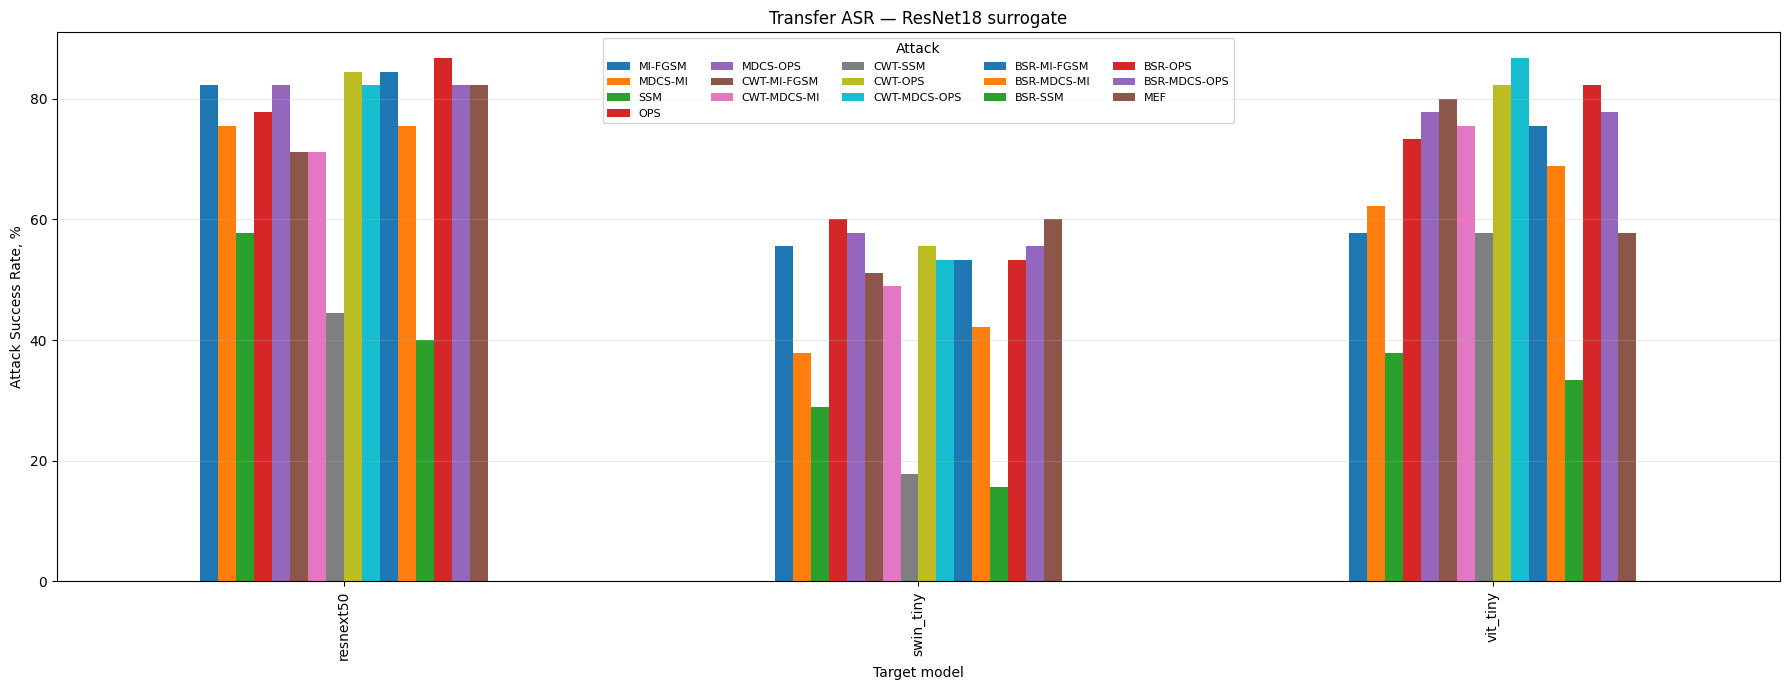

In [130]:
# Transfer ASR — source исключаем из grouped bar, чтобы график был именно про transfer.
plot_df = (
    transfer_df[(transfer_df["target"] != SOURCE_NAME) & transfer_df["attack"].isin(METHOD_ORDER)]
    .pivot(index="target", columns="attack", values="asr")
    * 100
)
plot_df = ordered_attack_columns(plot_df)

fig_transfer, ax = plt.subplots(figsize=(18, 7))
plot_df.plot(kind="bar", ax=ax)
ax.set_ylabel("Attack Success Rate, %")
ax.set_xlabel("Target model")
ax.set_title("Transfer ASR — ResNet18 surrogate")
ax.legend(title="Attack", ncol=5, fontsize=8)
ax.grid(axis="y", alpha=0.25)
fig_transfer.tight_layout()
transfer_fig_path = RUN_ROOT / "transfer_asr.png"
fig_transfer.savefig(transfer_fig_path, dpi=180)

# Локально сначала.
plt.show()

# ClearML после локального вывода.
report_figure_if_possible("transfer_asr", fig_transfer)

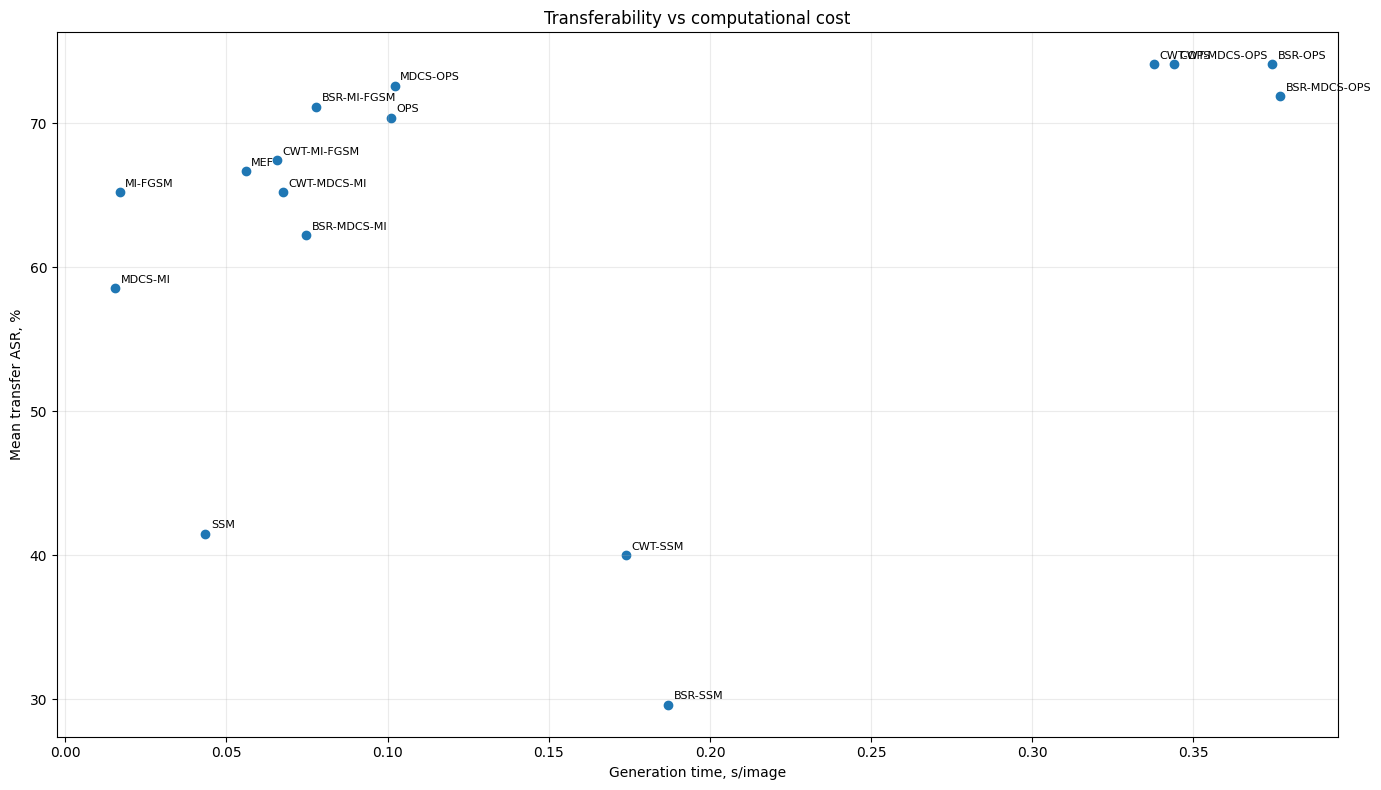

,attack,mean_transfer_asr,runtime_sec_per_image
0,MI-FGSM,65.185185,0.016880
1,MDCS-MI,58.518519,0.015483
2,SSM,41.481481,0.043457
3,OPS,70.370370,0.101145
4,MDCS-OPS,72.592593,0.102241
5,CWT-MI-FGSM,67.407407,0.065564
6,CWT-MDCS-MI,65.185185,0.067565
7,CWT-SSM,40.000000,0.173904
8,CWT-OPS,74.074074,0.337711
9,CWT-MDCS-OPS,74.074074,0.343838


In [131]:
mean_transfer = (
    transfer_df[(transfer_df["target"] != SOURCE_NAME) & transfer_df["attack"].isin(METHOD_ORDER)]
    .groupby("attack", as_index=False)
    .agg(
        mean_transfer_asr=("asr", "mean"),
        runtime_sec_per_image=("runtime_sec_per_image", "first"),
    )
)
mean_transfer["mean_transfer_asr"] *= 100

fig_runtime, ax = plt.subplots(figsize=(14, 8))
ax.scatter(
    mean_transfer["runtime_sec_per_image"],
    mean_transfer["mean_transfer_asr"],
)

for _, row in mean_transfer.iterrows():
    ax.annotate(
        METHOD_LABELS.get(row["attack"], row["attack"]),
        (
            row["runtime_sec_per_image"],
            row["mean_transfer_asr"],
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_xlabel("Generation time, s/image")
ax.set_ylabel("Mean transfer ASR, %")
ax.set_title("Transferability vs computational cost")
ax.grid(alpha=0.25)
fig_runtime.tight_layout()
runtime_fig_path = RUN_ROOT / "asr_vs_runtime.png"
fig_runtime.savefig(runtime_fig_path, dpi=180)

mean_transfer_path = RUN_ROOT / "mean_transfer_vs_runtime.csv"
mean_transfer.to_csv(mean_transfer_path, index=False)

plt.show()


report_figure_if_possible("asr_vs_runtime", fig_runtime)
report_table_if_possible("mean_transfer_vs_runtime", format_method_table(mean_transfer))

In [132]:
fig_jpeg = None

if jpeg_df is not None:
    jpeg_plot = (
        jpeg_df[(jpeg_df["target"] != SOURCE_NAME) & jpeg_df["attack"].isin(METHOD_ORDER)]
        .groupby(["attack", "jpeg_quality"], as_index=False)["asr"]
        .mean()
    )
    jpeg_plot["asr"] *= 100

    fig_jpeg, ax = plt.subplots(figsize=(8, 5))

    for attack_name in METHOD_ORDER:
        part = jpeg_plot[jpeg_plot["attack"] == attack_name]
        if part.empty:
            continue
        part = part.sort_values("jpeg_quality")
        ax.plot(
            part["jpeg_quality"],
            part["asr"],
            marker="o",
            label=METHOD_LABELS.get(attack_name, attack_name),
        )

    ax.set_xlabel("JPEG quality")
    ax.set_ylabel("Mean transfer ASR, %")
    ax.set_title("Attack persistence after JPEG preprocessing")
    ax.grid(alpha=0.25)
    ax.legend(ncol=2)

    fig_jpeg.tight_layout()
    jpeg_fig_path = RUN_ROOT / "jpeg_asr.png"
    fig_jpeg.savefig(jpeg_fig_path, dpi=180)

    plt.show()
    report_figure_if_possible("jpeg_asr", fig_jpeg)

## 13. Полный combined-report по всем RUN_ID

Объединяет `EXCLUDE_RUN_IDS + текущий RUN_ID`, сохраняя weighted summaries, итоговые таблицы и графики. Каждый run должен содержать все методы из `METHOD_ORDER`.

FULL COMBINED REPORT: ['hour_cwt_bsr_all_50']


,model,clean_accuracy,n
0,resnet18,0.90,50
1,resnext50,1.00,50
2,vit_tiny,0.98,50
3,swin_tiny,0.96,50


,attack,n,sec_per_image,mean_linf,max_linf
0,MI-FGSM,50,0.016880,0.062745,0.062745
1,MDCS-MI,50,0.015483,0.062745,0.062745
2,SSM,50,0.043457,0.062745,0.062745
3,OPS,50,0.101145,0.062745,0.062745
4,MDCS-OPS,50,0.102241,0.062745,0.062745
5,CWT-MI-FGSM,50,0.065564,0.062745,0.062745
6,CWT-MDCS-MI,50,0.067565,0.062745,0.062745
7,CWT-SSM,50,0.173904,0.062745,0.062745
8,CWT-OPS,50,0.337711,0.062745,0.062745
9,CWT-MDCS-OPS,50,0.343838,0.062745,0.062745


,attack,target,n_common_correct,asr_percent,mean_true_conf_drop,runtime_sec_per_image,mean_linf,max_linf
0,MI-FGSM,resnet18,45,100.000000,0.953567,0.016880,0.062745,0.062745
1,MI-FGSM,resnext50,45,82.222222,0.791828,0.016880,0.062745,0.062745
2,MI-FGSM,swin_tiny,45,55.555556,0.533445,0.016880,0.062745,0.062745
3,MI-FGSM,vit_tiny,45,57.777778,0.567203,0.016880,0.062745,0.062745
4,MDCS-MI,resnet18,45,100.000000,0.953567,0.015483,0.062745,0.062745
...,...,...,...,...,...,...,...,...
59,BSR-MDCS-OPS,vit_tiny,45,77.777778,0.770710,0.376808,0.062745,0.062745
60,MEF,resnet18,45,100.000000,0.953566,0.055962,0.062745,0.062745
61,MEF,resnext50,45,82.222222,0.793593,0.055962,0.062745,0.062745
62,MEF,swin_tiny,45,60.000000,0.634394,0.055962,0.062745,0.062745


,attack,mean_transfer_asr,runtime_sec_per_image
0,MI-FGSM,65.185185,0.016880
1,MDCS-MI,58.518519,0.015483
2,SSM,41.481481,0.043457
3,OPS,70.370370,0.101145
4,MDCS-OPS,72.592593,0.102241
5,CWT-MI-FGSM,67.407407,0.065564
6,CWT-MDCS-MI,65.185185,0.067565
7,CWT-SSM,40.000000,0.173904
8,CWT-OPS,74.074074,0.337711
9,CWT-MDCS-OPS,74.074074,0.343838


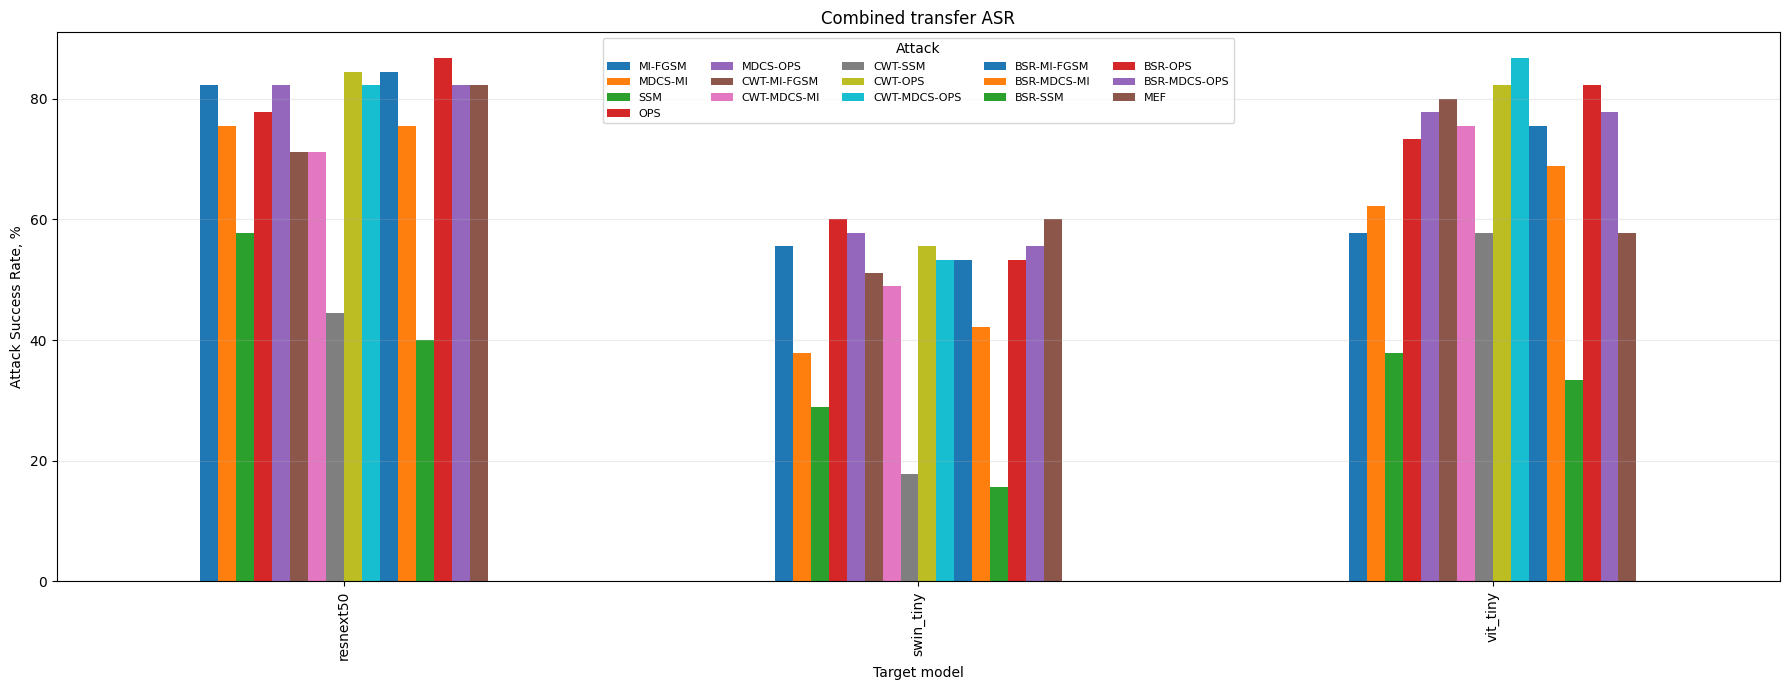

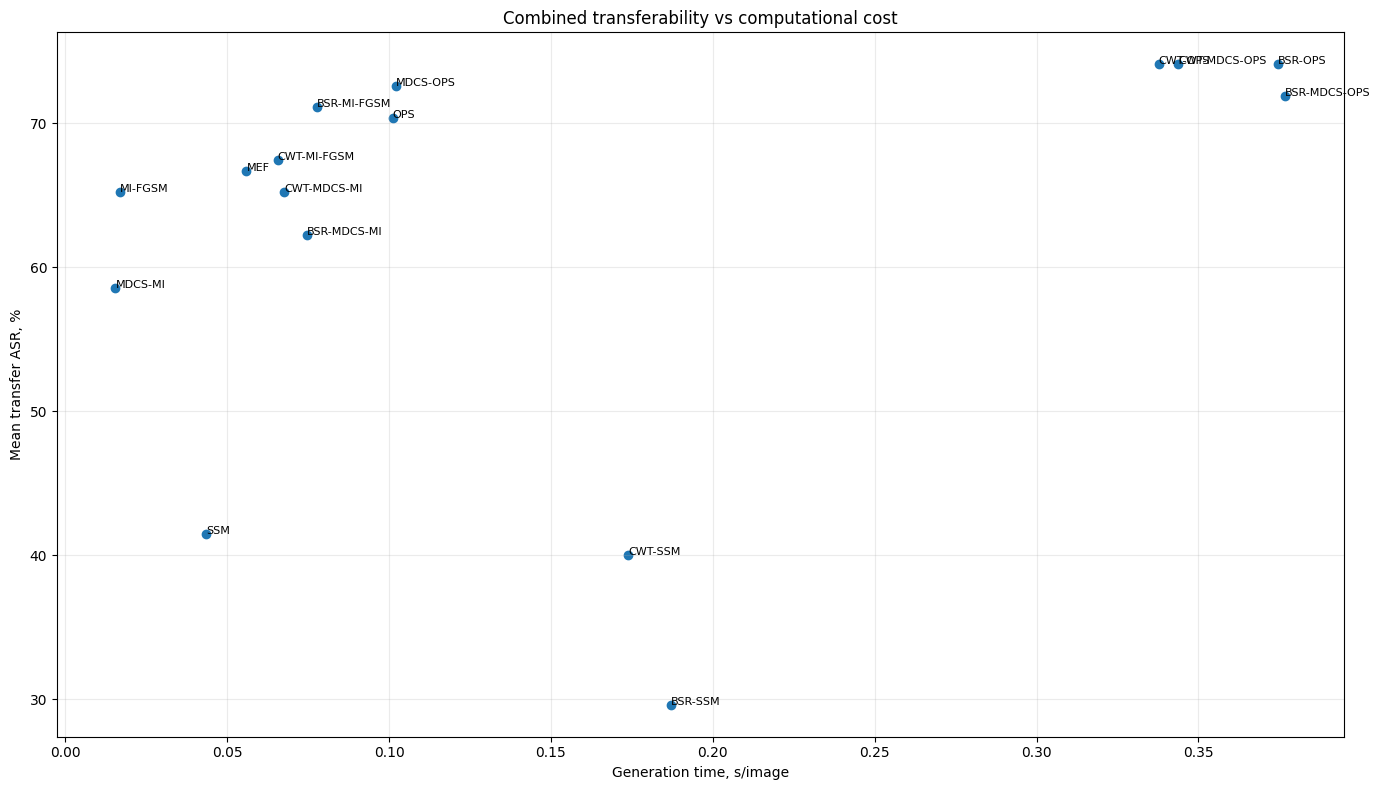

In [133]:
def load_run_csv(run_id, filename, required=True):
    local_path = WORK_ROOT / run_id / filename
    if not local_path.exists():
        fallback = WORK_ROOT / '_combined_runs' / run_id / filename
        local_path = fallback if fallback.exists() else local_path
    if not local_path.exists():
        if required:
            raise FileNotFoundError(f'Missing local run artifact: {local_path}')
        return None
    return pd.read_csv(local_path)

def weighted_mean(frame, value_column, weight_column):
    values = pd.to_numeric(frame[value_column], errors='coerce').to_numpy(float)
    weights = pd.to_numeric(frame[weight_column], errors='coerce').to_numpy(float)
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    return float(np.average(values[mask], weights=weights[mask])) if mask.any() else np.nan


combined_run_ids = [*EXCLUDE_RUN_IDS, RUN_ID]
if LOG_COMBINED_RESULTS:
    print('FULL COMBINED REPORT:', combined_run_ids)
    clean_parts, generation_parts_all, transfer_parts, jpeg_parts = [], [], [], []
    for run_id in combined_run_ids:
        clean_part = load_run_csv(run_id, 'clean_accuracy.csv')
        generation_part = load_run_csv(run_id, 'generation_summary.csv')
        transfer_part = load_run_csv(run_id, 'transfer_results.csv')
        available = set(transfer_part['attack'].astype(str))
        missing = [method for method in METHOD_ORDER if method not in available]
        if missing:
            raise RuntimeError(f'Combined report cannot use {run_id}: missing methods {missing}')
        if 'asr_percent' not in transfer_part:
            transfer_part['asr_percent'] = 100.0 * transfer_part['asr']
        clean_parts.append(clean_part)
        generation_parts_all.append(generation_part[generation_part['attack'].isin(METHOD_ORDER)])
        transfer_parts.append(transfer_part[transfer_part['attack'].isin(METHOD_ORDER)])
        jpeg_part = load_run_csv(run_id, 'jpeg_results.csv', required=False)
        if jpeg_part is not None:
            if 'asr_percent' not in jpeg_part:
                jpeg_part['asr_percent'] = 100.0 * jpeg_part['asr']
            jpeg_parts.append(jpeg_part[jpeg_part['attack'].isin(METHOD_ORDER)])

    clean_full = pd.concat(clean_parts, ignore_index=True)
    combined_clean_df = pd.DataFrame([{
        'model': model, 'clean_accuracy': weighted_mean(part, 'clean_accuracy', 'n'),
        'n': int(part['n'].sum()),
    } for model, part in clean_full.groupby('model', sort=False)])

    generation_full = pd.concat(generation_parts_all, ignore_index=True)
    combined_generation_df = pd.DataFrame([{
        'attack': attack, 'n': int(part['n'].sum()),
        'sec_per_image': weighted_mean(part, 'sec_per_image', 'n'),
        'mean_linf': weighted_mean(part, 'mean_linf', 'n'),
        'max_linf': float(part['max_linf'].max()),
    } for attack, part in generation_full.groupby('attack', sort=False)])

    transfer_full = pd.concat(transfer_parts, ignore_index=True)
    combined_transfer_df = pd.DataFrame([{
        'attack': attack, 'target': target,
        'n_common_correct': int(part['n_common_correct'].sum()),
        'asr_percent': weighted_mean(part, 'asr_percent', 'n_common_correct'),
        'mean_true_conf_drop': weighted_mean(part, 'mean_true_conf_drop', 'n_common_correct'),
        'runtime_sec_per_image': weighted_mean(part, 'runtime_sec_per_image', 'n_common_correct'),
        'mean_linf': weighted_mean(part, 'mean_linf', 'n_common_correct'),
        'max_linf': float(part['max_linf'].max()),
    } for (attack, target), part in transfer_full.groupby(['attack', 'target'], sort=False)])

    transfer_only = combined_transfer_df[combined_transfer_df['target'] != SOURCE_NAME]
    combined_mean_transfer_df = (transfer_only.groupby('attack', as_index=False)
        .agg(mean_transfer_asr=('asr_percent', 'mean'))
        .merge(combined_generation_df[['attack', 'sec_per_image']].rename(
            columns={'sec_per_image': 'runtime_sec_per_image'}), on='attack', how='left'))

    combined_tables = {
        'combined_clean_accuracy.csv': combined_clean_df,
        'combined_generation_summary.csv': combined_generation_df,
        'combined_transfer_results.csv': combined_transfer_df,
        'combined_mean_transfer_vs_runtime.csv': combined_mean_transfer_df,
    }
    for filename, frame in combined_tables.items():
        path = RUN_ROOT / filename
        frame.to_csv(path, index=False)
        report_table_if_possible(filename.removesuffix('.csv'), format_method_table(frame))

    combined_plot = ordered_attack_columns(combined_transfer_df[
        combined_transfer_df['target'] != SOURCE_NAME
    ].pivot(index='target', columns='attack', values='asr_percent'))
    fig_combined_transfer, ax = plt.subplots(figsize=(18, 7))
    combined_plot.plot(kind='bar', ax=ax)
    ax.set(xlabel='Target model', ylabel='Attack Success Rate, %', title='Combined transfer ASR')
    ax.legend(title='Attack', ncol=5, fontsize=8)
    ax.grid(axis='y', alpha=0.25)
    fig_combined_transfer.tight_layout()
    combined_transfer_plot_path = RUN_ROOT / 'combined_transfer_asr.png'
    fig_combined_transfer.savefig(combined_transfer_plot_path, dpi=180)
    plt.show()

    fig_combined_runtime, ax = plt.subplots(figsize=(14, 8))
    ax.scatter(combined_mean_transfer_df['runtime_sec_per_image'], combined_mean_transfer_df['mean_transfer_asr'])
    for row in combined_mean_transfer_df.itertuples(index=False):
        ax.annotate(METHOD_LABELS.get(row.attack, row.attack),
                    (row.runtime_sec_per_image, row.mean_transfer_asr), fontsize=8)
    ax.set(xlabel='Generation time, s/image', ylabel='Mean transfer ASR, %',
           title='Combined transferability vs computational cost')
    ax.grid(alpha=0.25)
    fig_combined_runtime.tight_layout()
    combined_runtime_plot_path = RUN_ROOT / 'combined_asr_vs_runtime.png'
    fig_combined_runtime.savefig(combined_runtime_plot_path, dpi=180)
    plt.show()

    for path, figure, title in (
        (combined_transfer_plot_path, fig_combined_transfer, 'combined_transfer_asr'),
        (combined_runtime_plot_path, fig_combined_runtime, 'combined_asr_vs_runtime'),
    ):
        report_figure_if_possible(title, figure, series='combined')

    if jpeg_parts:
        jpeg_full = pd.concat(jpeg_parts, ignore_index=True)
        combined_jpeg_df = pd.DataFrame([{
            'attack': attack, 'target': target, 'jpeg_quality': int(quality),
            'n_common_correct': int(part['n_common_correct'].sum()),
            'asr_percent': weighted_mean(part, 'asr_percent', 'n_common_correct'),
        } for (attack, target, quality), part in jpeg_full.groupby(
            ['attack', 'target', 'jpeg_quality'], sort=False)])
        combined_jpeg_path = RUN_ROOT / 'combined_jpeg_results.csv'
        combined_jpeg_df.to_csv(combined_jpeg_path, index=False)
        report_table_if_possible('combined_jpeg_results', format_method_table(combined_jpeg_df))
        jpeg_transfer = combined_jpeg_df[combined_jpeg_df['target'] != SOURCE_NAME]
        jpeg_plot_rows = [{
            'attack': attack, 'jpeg_quality': int(quality),
            'asr_percent': weighted_mean(part, 'asr_percent', 'n_common_correct'),
        } for (attack, quality), part in jpeg_transfer.groupby(['attack', 'jpeg_quality'], sort=False)]
        jpeg_plot = pd.DataFrame(jpeg_plot_rows)
        fig_combined_jpeg, ax = plt.subplots(figsize=(14, 7))
        for attack in METHOD_ORDER:
            part = jpeg_plot[jpeg_plot['attack'] == attack].sort_values('jpeg_quality')
            if not part.empty:
                ax.plot(part['jpeg_quality'], part['asr_percent'], marker='o',
                        label=METHOD_LABELS.get(attack, attack))
        ax.set(xlabel='JPEG quality', ylabel='Mean transfer ASR, %',
               title='Combined attack persistence after JPEG preprocessing')
        ax.grid(alpha=0.25)
        ax.legend(ncol=4, fontsize=8)
        fig_combined_jpeg.tight_layout()
        combined_jpeg_plot_path = RUN_ROOT / 'combined_jpeg_asr.png'
        fig_combined_jpeg.savefig(combined_jpeg_plot_path, dpi=180)
        plt.show()
        report_figure_if_possible('combined_jpeg_asr', fig_combined_jpeg, series='combined')
else:
    print('LOG_COMBINED_RESULTS=False — combined report skipped.')

## 13. Финальная sanity-check + закрытие ClearML

In [134]:
# Проверяем, что у каждой атаки есть результаты на всех четырех моделях.
expected_targets = set(MODEL_SPECS.keys())

for method in METHODS_TO_RUN:
    got = set(
        transfer_df.loc[
            transfer_df["attack"] == method,
            "target",
        ]
    )
    assert got == expected_targets, (method, got, expected_targets)

selected_cwt = set(METHODS_TO_RUN) & set(CWT_BASE_METHODS)
assert selected_cwt <= set(transfer_df["attack"].unique())
for method in selected_cwt:
    cfg = jsonable_attack_config(method)
    assert cfg["base_method"] == CWT_BASE_METHODS[method]
    assert cfg["cwt"]["copies"] == CWT_COPIES
    assert ATTACK_CONFIG[method]["batch_size"] == 1
    assert (ATTACK_ROOT / method / "config.json").exists()

selected_bsr = set(METHODS_TO_RUN) & set(BSR_BASE_METHODS)
assert selected_bsr <= set(transfer_df["attack"].unique())
for method in selected_bsr:
    cfg = jsonable_attack_config(method)
    assert cfg["base_method"] == BSR_BASE_METHODS[method]
    assert cfg["bsr"]["copies"] == BSR_COPIES
    assert ATTACK_CONFIG[method]["batch_size"] == 1
    assert (ATTACK_ROOT / method / "config.json").exists()

# Не должно быть нарушений epsilon.
assert transfer_df["max_linf"].max() <= EPS + 1e-5

# Все знаменатели логируем явно.
if (transfer_df["n_common_correct"] == 0).any():
    print("WARNING: есть target с n_common_correct=0")
    display(
        transfer_df[transfer_df["n_common_correct"] == 0]
    )


# Финальный локальный marker: позволяет отличить полностью завершенный run от частичного.
complete_marker = RUN_ROOT / "RUN_COMPLETE.json"
complete_marker.write_text(
    json.dumps(
        {
            "run_id": RUN_ID,
            "run_profile": RUN_PROFILE,
            "status": "complete",
            "repo_commit": repo_commit,
            "mef_repo_commit": mef_repo_commit,
            "methods": list(METHODS_TO_RUN),
            "num_attack_samples": NUM_ATTACK_SAMPLES,
            "epsilon": EPS,
            "steps": STEPS,
            "cwt_copies": CWT_COPIES,
            "cwt_base_methods": dict(CWT_BASE_METHODS),
            "bsr_copies": BSR_COPIES,
            "bsr_base_methods": dict(BSR_BASE_METHODS),
        },
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

print("\nDONE")
print("Artifacts:")
for p in sorted(RUN_ROOT.rglob("*")):
    if p.is_file():
        print(" ", p.relative_to(RUN_ROOT))

if clearml_task is not None:
    try:
        clearml_task.close()
        print("ClearML task closed.")
    except Exception as e:
        print("ClearML close failed:", e)


DONE
Artifacts:
  RUN_COMPLETE.json
  adv_batches/bsr_mdcs_mi/batch_0000.pt
  adv_batches/bsr_mdcs_mi/batch_0001.pt
  adv_batches/bsr_mdcs_mi/batch_0002.pt
  adv_batches/bsr_mdcs_mi/batch_0003.pt
  adv_batches/bsr_mdcs_mi/batch_0004.pt
  adv_batches/bsr_mdcs_mi/batch_0005.pt
  adv_batches/bsr_mdcs_mi/batch_0006.pt
  adv_batches/bsr_mdcs_mi/batch_0007.pt
  adv_batches/bsr_mdcs_mi/batch_0008.pt
  adv_batches/bsr_mdcs_mi/batch_0009.pt
  adv_batches/bsr_mdcs_mi/batch_0010.pt
  adv_batches/bsr_mdcs_mi/batch_0011.pt
  adv_batches/bsr_mdcs_mi/batch_0012.pt
  adv_batches/bsr_mdcs_mi/batch_0013.pt
  adv_batches/bsr_mdcs_mi/batch_0014.pt
  adv_batches/bsr_mdcs_mi/batch_0015.pt
  adv_batches/bsr_mdcs_mi/batch_0016.pt
  adv_batches/bsr_mdcs_mi/batch_0017.pt
  adv_batches/bsr_mdcs_mi/batch_0018.pt
  adv_batches/bsr_mdcs_mi/batch_0019.pt
  adv_batches/bsr_mdcs_mi/batch_0020.pt
  adv_batches/bsr_mdcs_mi/batch_0021.pt
  adv_batches/bsr_mdcs_mi/batch_0022.pt
  adv_batches/bsr_mdcs_mi/batch_0023.pt
  a

## Финальные результаты

Все checkpoints, attack batches, configs, CSV и графики сохраняются локально в:

```text
/kaggle/working/transfer_imagewoof/<RUN_ID>/
```

Чтобы результаты попали в Kaggle Output, выполните **Save Version** после завершения ноутбука.